# 1. Comprensión del Negocio

## Objetivo del Negocio

El objetivo de este proyecto es **desarrollar un sistema de segmentación de clientes** mediante técnicas de *Machine Learning* que permita identificar grupos con comportamientos de compra similares y generar **recomendaciones de productos personalizadas** para cada segmento.

La solución busca apoyar la toma de decisiones comerciales, incrementando el valor generado para los clientes y contribuyendo al aumento del ticket promedio y de las ventas de productos recomendados.

---

## Preguntas de Negocio

El Análisis Exploratorio de Datos (EDA) estará orientado a responder las siguientes preguntas estratégicas:

### Comportamiento de los clientes

- ¿Quiénes son los clientes que generan mayores ingresos?
- ¿Qué clientes realizan compras con mayor frecuencia?
- ¿Existen clientes con alto potencial de fidelización?
- ¿Existen clientes inactivos o con riesgo de abandono?
- ¿Cuál es el valor promedio de compra por cliente?

---

### Comportamiento de compra

- ¿Qué productos son los más vendidos?
- ¿Qué productos generan mayores ingresos?
- ¿Qué productos suelen comprarse en conjunto?
- ¿Cuál es el tamaño promedio de las compras?

---

### Análisis temporal

- ¿Cómo evolucionan las ventas a lo largo del tiempo?
- ¿Existen patrones estacionales o meses con mayor demanda?
- ¿Con qué frecuencia realizan compras los clientes?

---

### Análisis geográfico

- ¿Qué países generan el mayor volumen de ventas?
- ¿Cuál es la distribución geográfica de los clientes?

---

## Objetivo del EDA

El análisis exploratorio permitirá comprender el comportamiento de compra de los clientes, identificar problemas de calidad en los datos y construir las variables necesarias para el modelo de segmentación y el sistema de recomendaciones.

Al finalizar esta etapa se espera:

- Comprender la estructura y calidad del conjunto de datos.
- Identificar patrones de compra relevantes.
- Detectar valores atípicos, devoluciones y registros inconsistentes.
- Definir las variables que representarán el comportamiento de cada cliente.
- Establecer la base para el desarrollo del modelo de segmentación y del motor de recomendaciones.

In [1]:
#Carga de Datos
import pandas as pd
import numpy as np

df = pd.read_csv(
    "../data/raw/online_retail_II.csv",
    sep=",",
    encoding="utf-8-sig"   # elimina el BOM (\ufeff) del inicio
)


# 2 Comprensión del Dataset

El conjunto de datos **Online Retail II** contiene **1.067.371 registros** y **8 variables**, correspondientes a las transacciones realizadas por una empresa de comercio electrónico entre **diciembre de 2009 y diciembre de 2011**.

Cada registro representa una línea de una factura e incluye información relacionada con el producto adquirido, la cantidad comprada, el precio unitario, el cliente y el país de origen de la compra.

---

# Estructura del Dataset

| Característica | Valor |
|----------------|------:|
| Número de registros | **1.067.371** |
| Número de variables | **8** |
| Memoria utilizada | **65,1 MB** |
| Variables numéricas | **3** |
| Variables categóricas | **5** |

---

# Descripción de las Variables

| Variable | Tipo de dato | Descripción |
|----------|--------------|-------------|
| **Invoice** | Object | Número de factura o transacción. |
| **StockCode** | Object | Código único del producto. |
| **Description** | Object | Descripción del producto. |
| **Quantity** | Int64 | Cantidad de unidades compradas. |
| **InvoiceDate** | Object | Fecha y hora de la transacción (requiere conversión a tipo `datetime`). |
| **Price** | Float64 | Precio unitario del producto. |
| **Customer ID** | Float64 | Identificador único del cliente. |
| **Country** | Object | País de origen del cliente. |

---

# Calidad Inicial de los Datos

El análisis preliminar muestra que la mayoría de las variables están completas. Sin embargo, se identifican dos columnas con valores faltantes que deben ser consideradas antes del proceso de modelado.

| Variable | Valores nulos | % de nulos |
|----------|--------------:|-----------:|
| **Description** | 4.382 | **0,41 %** |
| **Customer ID** | 243.007 | **22,77 %** |

---

# Observaciones Iniciales

### Variables completas

Las siguientes variables **no presentan valores nulos**, lo que garantiza la integridad de la información transaccional:

- Invoice
- StockCode
- Quantity
- InvoiceDate
- Price
- Country

### Variable **Description**

- Presenta únicamente **4.382 registros faltantes (0,41 %)**.
- Su impacto sobre el análisis es mínimo.
- Dependiendo del contexto, estos registros podrán eliminarse o mantenerse si la descripción no es indispensable para el modelo.

### Variable **Customer ID**

La variable **Customer ID** presenta **243.007 valores faltantes**, equivalentes al **22,77 %** del conjunto de datos.

Este constituye el principal desafío del proyecto, ya que los modelos de segmentación basados en clientes requieren identificar de forma única a cada comprador.

Como consecuencia:

- Para el **Análisis Exploratorio (EDA)** se utilizará el conjunto completo de datos.
- Para la construcción del modelo será necesario excluir los registros que no poseen **Customer ID**.
- El modelo **FP-Growth** podrá aprovechar prácticamente todas las transacciones válidas, ya que trabaja sobre las combinaciones de productos dentro de las facturas y no depende del identificador del cliente.

---

# Conclusiones Iniciales

A partir de esta revisión preliminar se identifican las siguientes oportunidades y retos:

- El dataset presenta un volumen de información suficiente para desarrollar modelos de segmentación y recomendación.
- La calidad general de los datos es alta, con un bajo porcentaje de valores faltantes en la mayoría de las variables.
- La ausencia de **Customer ID** en el **22,77 %** de los registros condiciona el uso de modelos basados en comportamiento individual.
- Será necesario realizar una etapa de limpieza y preparación de datos antes de construir las variables y entrenar el modelo de **Clustering**.
- Las reglas de asociación mediante **FP-Growth** permitirán aprovechar un mayor porcentaje de las transacciones para generar recomendaciones de productos.

In [2]:
df.shape

df.info()

df.describe(include='all')

df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


# 3. Calidad de los Datos

En esta etapa se evalúa la calidad del conjunto de datos con el fin de identificar problemas que puedan afectar el análisis y el entrenamiento de los modelos de Machine Learning.

Se analizarán los siguientes aspectos:

- Dimensiones del dataset.
- Tipos de datos.
- Valores faltantes.
- Registros duplicados.
- Valores únicos.
- Valores negativos.
- Facturas canceladas.
- Consistencia de las variables.# 3. Calidad de los Datos

En esta etapa se evalúa la calidad del conjunto de datos con el fin de identificar problemas que puedan afectar el análisis y el entrenamiento de los modelos de Machine Learning.

Se analizarán los siguientes aspectos:

- Dimensiones del dataset.
- Tipos de datos.
- Valores faltantes.
- Registros duplicados.
- Valores únicos.
- Valores negativos.
- Facturas canceladas.
- Consistencia de las variables.

In [3]:
# 3.1 Dimensiones del Dataset
print("="*60)
print("DIMENSIONES DEL DATASET")
print("="*60)

print(f"Número de registros : {df.shape[0]:,}")
print(f"Número de variables : {df.shape[1]}")

DIMENSIONES DEL DATASET
Número de registros : 1,067,371
Número de variables : 8


In [4]:
# 3.2 Tipos de datos
print("="*60)
print("TIPOS DE DATOS")
print("="*60)

df.dtypes

df.info()

TIPOS DE DATOS
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype  
---  ------       --------------    -----  
 0   Invoice      1067371 non-null  object 
 1   StockCode    1067371 non-null  object 
 2   Description  1062989 non-null  object 
 3   Quantity     1067371 non-null  int64  
 4   InvoiceDate  1067371 non-null  object 
 5   Price        1067371 non-null  float64
 6   Customer ID  824364 non-null   float64
 7   Country      1067371 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 65.1+ MB


In [5]:
# 3.3 Valores faltantes

missing = pd.DataFrame({
    "Valores Nulos": df.isnull().sum(),
    "% Nulos": round(df.isnull().mean()*100,2)
})

missing.sort_values("% Nulos", ascending=False)

,Valores Nulos,% Nulos
Customer ID,243007,22.77
Description,4382,0.41
Invoice,0,0.00
StockCode,0,0.00
Quantity,0,0.00
InvoiceDate,0,0.00
Price,0,0.00
Country,0,0.00


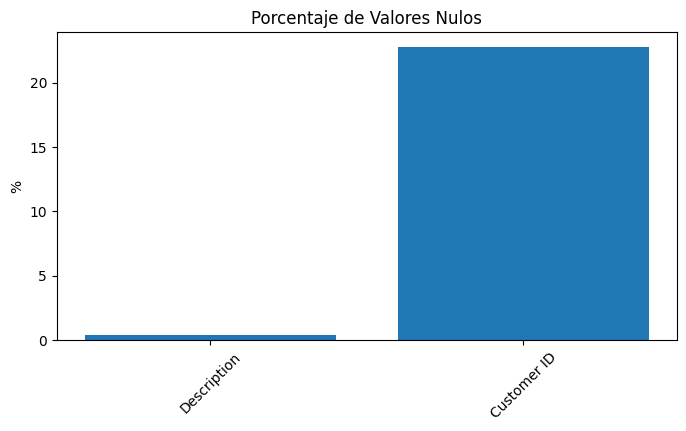

In [6]:
# Visualización

import matplotlib.pyplot as plt

missing = missing[missing["Valores Nulos"]>0]

plt.figure(figsize=(8,4))

plt.bar(
    missing.index,
    missing["% Nulos"]
)

plt.title("Porcentaje de Valores Nulos")

plt.ylabel("%")

plt.xticks(rotation=45)

plt.show()


In [7]:
# 3.4 Registros duplicados
duplicados = df.duplicated().sum()

print(f"Registros duplicados: {duplicados:,}")

Registros duplicados: 34,335


In [8]:
# 3.5 Valores únicos
pd.DataFrame({
    "Valores únicos": df.nunique()
}).sort_values("Valores únicos", ascending=False)

,Valores únicos
Invoice,53628
InvoiceDate,47635
Customer ID,5942
Description,5698
StockCode,5305
Price,2807
Quantity,1057
Country,43


In [9]:
# 3.6 Valores negativos - Cantidad
cantidad_negativa = (df["Quantity"] < 0).sum()

print(f"Cantidad negativa: {cantidad_negativa:,}")

Cantidad negativa: 22,950


In [10]:
# 3.6 Valores negativos - Precio
precio_negativo = (df["Price"] < 0).sum()

print(f"Precio negativo: {precio_negativo:,}")

Precio negativo: 5


In [11]:
# Precio igual a cero
precio_cero = (df["Price"] == 0).sum()

print(f"Precio igual a cero: {precio_cero:,}")

Precio igual a cero: 6,202


In [12]:
# Facturas canceladas
# En este dataset las devoluciones comienzan con la letra C.

canceladas = df["Invoice"].astype(str).str.startswith("C").sum()

print(f"Facturas canceladas: {canceladas:,}")

print(f"Porcentaje: {canceladas/len(df)*100:.2f}%")

Facturas canceladas: 19,494
Porcentaje: 1.83%


In [13]:
# Clientes sin identificación

clientes_sin_id = df["Customer ID"].isnull().sum()

print(f"Clientes sin ID: {clientes_sin_id:,}")

print(f"Porcentaje: {clientes_sin_id/len(df)*100:.2f}%")

Clientes sin ID: 243,007
Porcentaje: 22.77%


In [14]:
# Verificar de fechas

df["InvoiceDate"].head()

0    2009-12-01 07:45:00
1    2009-12-01 07:45:00
2    2009-12-01 07:45:00
3    2009-12-01 07:45:00
4    2009-12-01 07:45:00
Name: InvoiceDate, dtype: object

In [15]:
# Conversión de fechas

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

df["InvoiceDate"].dtype

dtype('<M8[ns]')

In [16]:
# Consistencia de los datos

(df["Quantity"] == 0).sum()

0

In [17]:
(df["Price"] <= 0).sum()

6207

In [18]:
# Total de venta

df["Total"] = df["Quantity"] * df["Price"]

In [19]:
(df["Total"] <= 0).sum()

25700

In [20]:
# Estadísticas descriptivas

df.describe().T

,count,mean,min,25%,50%,75%,max,std
Quantity,1067371.0,9.938898,-80995.0,1.0,3.0,10.0,80995.0,172.705794
InvoiceDate,1067371,2011-01-02 21:13:55.394028544,2009-12-01 07:45:00,2010-07-09 09:46:00,2010-12-07 15:28:00,2011-07-22 10:23:00,2011-12-09 12:50:00,NaN
Price,1067371.0,4.649388,-53594.36,1.25,2.1,4.15,38970.0,123.553059
Customer ID,824364.0,15324.638504,12346.0,13975.0,15255.0,16797.0,18287.0,1697.46445
Total,1067371.0,18.069866,-168469.6,3.75,9.9,17.7,168469.6,292.420223


In [21]:
# Resumen de Calidad
print("="*60)
print("RESUMEN DE CALIDAD")
print("="*60)

print(f"Registros                 : {len(df):,}")
print(f"Duplicados                : {df.duplicated().sum():,}")
print(f"Nulos                     : {df.isnull().sum().sum():,}")
print(f"Clientes sin ID           : {df['Customer ID'].isnull().sum():,}")
print(f"Facturas canceladas       : {df['Invoice'].astype(str).str.startswith('C').sum():,}")
print(f"Cantidad negativa         : {(df['Quantity']<0).sum():,}")
print(f"Cantidad igual a cero     : {(df['Quantity']==0).sum():,}")
print(f"Precio menor o igual a 0  : {(df['Price']<=0).sum():,}")

RESUMEN DE CALIDAD
Registros                 : 1,067,371
Duplicados                : 34,335
Nulos                     : 247,389
Clientes sin ID           : 243,007
Facturas canceladas       : 19,494
Cantidad negativa         : 22,950
Cantidad igual a cero     : 0
Precio menor o igual a 0  : 6,207


# Análisis de la Calidad de los Datos

El análisis de calidad del conjunto de datos permitió identificar las principales inconsistencias que deberán ser tratadas antes de construir el modelo de segmentación de clientes y el sistema de recomendaciones.

## Resumen de Calidad

| Indicador | Valor |
|-----------|------:|
| Registros totales | **1.067.371** |
| Registros duplicados | **34.335** |
| Valores nulos | **247.389** |
| Clientes sin identificación (Customer ID) | **243.007** |
| Facturas canceladas | **19.494** |
| Cantidades negativas | **22.950** |
| Cantidades iguales a cero | **0** |
| Precios menores o iguales a cero | **6.207** |

---

## Análisis de los resultados

### Registros duplicados

Se identificaron **34.335 registros duplicados**, lo que representa aproximadamente el **3,22 %** del conjunto de datos.

Estos registros pueden generar una sobreestimación de las ventas, la frecuencia de compra y el valor monetario de los clientes, por lo que deberán eliminarse durante la etapa de limpieza.

---

### Valores faltantes

El conjunto de datos presenta **247.389 valores faltantes**, concentrados principalmente en las variables **Customer ID** y **Description**.

La mayor parte de los datos faltantes corresponde a la variable **Customer ID**, la cual contiene **243.007 registros sin identificar** (22,77 % del total).

---

### Clientes sin identificación

La ausencia del identificador del cliente constituye el principal desafío del proyecto.

Dado que el modelo requiere construir un historial de compras para cada cliente, estos registros **no podrán utilizarse para el proceso de segmentación**.

Sin embargo, estas transacciones sí podrán ser aprovechadas durante el análisis exploratorio y en la construcción de reglas de asociación mediante **FP-Growth**, ya que este algoritmo trabaja sobre las facturas y los productos comprados, sin depender de la identificación del cliente.

---

### Facturas canceladas

Se identificaron **19.494 facturas canceladas**, las cuales se reconocen porque el número de factura comienza con la letra **"C"**.

Estas transacciones corresponden a devoluciones de productos y generan cantidades negativas dentro del conjunto de datos.

Su tratamiento dependerá del objetivo del análisis; sin embargo, para la construcción del modelo RFM se recomienda excluirlas, ya que no representan compras efectivas del cliente.

---

### Cantidades negativas

Se encontraron **22.950 registros con cantidades negativas**.

Este comportamiento está directamente relacionado con las devoluciones registradas en las facturas canceladas.

Antes del entrenamiento del modelo será necesario validar que todos estos registros correspondan efectivamente a devoluciones y definir si deben eliminarse o analizarse por separado.

---

### Cantidades iguales a cero

No se encontraron registros con cantidades iguales a cero.

Esto indica que todas las transacciones representan movimientos reales de inventario, ya sean compras o devoluciones.

---

### Precios menores o iguales a cero

Se identificaron **6.207 registros con precios menores o iguales a cero**.

Estos registros pueden corresponder a:

- Productos promocionales.
- Muestras gratuitas.
- Errores de captura.
- Ajustes administrativos.

Será necesario revisar estos casos antes del modelado, ya que podrían afectar el cálculo.

---

# Impacto sobre el proyecto

Con base en este análisis se establecen las siguientes decisiones para la fase de preparación de datos:

| Problema identificado | Acción propuesta |
|------------------------|------------------|
| Registros duplicados | Eliminar duplicados. |
| Customer ID nulo | Excluir únicamente para la construcción del modelo. |
| Description nula | Evaluar su eliminación o mantener el registro si no afecta el análisis. |
| Facturas canceladas | Excluir del modelo; conservar para análisis de devoluciones si es necesario. |
| Cantidades negativas | Validar su relación con devoluciones y excluir del modelo de segmentación. |
| Precio menor o igual a cero | Revisar caso a caso y excluir aquellos que no representen ventas reales. |

---

# Conclusiones

La calidad general del conjunto de datos es adecuada para el desarrollo del proyecto. No obstante, se identificaron algunos aspectos que requieren tratamiento previo al modelado:

- El porcentaje de registros duplicados es bajo y puede corregirse fácilmente.
- La ausencia del **Customer ID** en el **22,77 %** de las transacciones limita el uso de estos registros para la segmentación de clientes, aunque no afecta el análisis mediante reglas de asociación.
- Las devoluciones representan una parte importante del conjunto de datos y deberán tratarse de manera independiente para evitar sesgos en el cálculo de las variables.
- Después del proceso de limpieza, el conjunto de datos conservará un volumen suficiente de información para construir un modelo robusto de segmentación y un sistema de recomendación basado en patrones de compra.

# 4. Limpieza de los Datos

## Objetivo

El objetivo de esta etapa es preparar un conjunto de datos consistente y confiable para la construcción del modelo de segmentación de clientes y del sistema de recomendaciones .

Con base en el análisis de calidad realizado anteriormente, se aplicarán los siguientes criterios de limpieza:

- Eliminar registros duplicados.
- Eliminar registros sin **Customer ID**.
- Eliminar facturas canceladas.
- Eliminar registros con cantidades negativas.
- Eliminar registros con precio igual a cero.

Al finalizar esta etapa se obtendrá un conjunto de datos limpio, listo para el proceso de ingeniería de características y modelado.

In [22]:
# Número inicial de registros
registros_iniciales = len(df)

# Customer ID nulos
customer_id_nulos = df["Customer ID"].isnull().sum()

# Facturas canceladas
facturas_canceladas = df["Invoice"].astype(str).str.startswith("C").sum()

# Cantidades negativas
cantidades_negativas = (df["Quantity"] < 0).sum()

# Precio igual a cero
precio_cero = (df["Price"] == 0).sum()

In [23]:
# Copia del dataset original
df_clean = df.copy()

print(f"Registros iniciales: {len(df_clean):,}")


Registros iniciales: 1,067,371


## Eliminación de registros duplicados

Los registros duplicados representan transacciones repetidas que pueden generar una sobreestimación de las ventas y afectar el cálculo de las variables.

Por esta razón, todos los registros duplicados serán eliminados.

In [24]:
# duplicados = df_clean.duplicated().sum()

# print(f"Duplicados encontrados: {duplicados:,}")

# df_clean.drop_duplicates(inplace=True)

# print(f"Registros después de eliminar duplicados: {len(df_clean):,}")

In [25]:
# Registros con Quantity >= 1800 o Price >= 250
outliers = df_clean[
    (df_clean["Quantity"] >= 1800) |
    (df_clean["Price"] >= 250)
]

print(f"Registros a eliminar: {len(outliers):,}")

display(outliers.head(10))

Registros a eliminar: 1,112


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Total
2379,489597,DOT,DOTCOM POSTAGE,1,2009-12-01 14:28:00,647.19,NaN,United Kingdom,647.19
5063,489856,DOT,DOTCOM POSTAGE,1,2009-12-02 14:36:00,470.24,NaN,United Kingdom,470.24
5407,489857,DOT,DOTCOM POSTAGE,1,2009-12-02 14:43:00,775.24,NaN,United Kingdom,775.24
7302,490018,21981,PACK OF 12 WOODLAND TISSUES,4320,2009-12-03 12:31:00,0.25,17940.0,United Kingdom,1080.00
7303,490018,21967,PACK OF 12 SKULL TISSUES,5184,2009-12-03 12:31:00,0.25,17940.0,United Kingdom,1296.00
7304,490018,21984,PACK OF 12 PINK PAISLEY TISSUES,4008,2009-12-03 12:31:00,0.25,17940.0,United Kingdom,1002.00
7305,490018,21980,PACK OF 12 RED SPOTTY TISSUES,4008,2009-12-03 12:31:00,0.25,17940.0,United Kingdom,1002.00
8374,490074,DOT,DOTCOM POSTAGE,1,2009-12-03 14:39:00,862.67,NaN,United Kingdom,862.67
9307,C490129,M,Manual,-1,2009-12-03 18:26:00,1998.49,15482.0,United Kingdom,-1998.49
9701,490149,DOT,DOTCOM POSTAGE,1,2009-12-04 09:43:00,922.05,NaN,United Kingdom,922.05


In [26]:
# Eliminar registros con Quantity >= 1800 o Price >= 250
df_clean = df_clean[
    (df_clean["Quantity"] < 1800) &
    (df_clean["Price"] < 250)
].copy()

# Reiniciar el índice
df_clean.reset_index(drop=True, inplace=True)

print(f"Registros después de la limpieza: {len(df_clean):,}")

Registros después de la limpieza: 1,066,259


## Eliminación de registros sin Customer ID

El modelo requiere identificar de manera única cada cliente para calcular su comportamiento de compra.

Por esta razón, se eliminarán los registros que no contienen información en la variable **Customer ID**.

In [27]:
sin_cliente = df_clean["Customer ID"].isna().sum()

print(f"Clientes sin ID: {sin_cliente:,}")

df_clean = df_clean[df_clean["Customer ID"].notna()]

print(f"Registros después de eliminar Customer ID nulos: {len(df_clean):,}")

Clientes sin ID: 242,397
Registros después de eliminar Customer ID nulos: 823,862


## Eliminación de facturas canceladas

Las facturas cuyo número inicia con la letra **"C"** corresponden a devoluciones de productos.

Estas transacciones no representan compras efectivas y pueden alterar el cálculo del gasto total y la frecuencia de compra del cliente.

Por esta razón, serán excluidas del conjunto de datos utilizado para el modelo de segmentación.

In [28]:
canceladas = df_clean["Invoice"].astype(str).str.startswith("C").sum()

print(f"Facturas canceladas: {canceladas:,}")

df_clean = df_clean[
    ~df_clean["Invoice"].astype(str).str.startswith("C")
]

print(f"Registros después de eliminar cancelaciones: {len(df_clean):,}")

Facturas canceladas: 18,549
Registros después de eliminar cancelaciones: 805,313


## Eliminación de cantidades negativas

Las cantidades negativas corresponden principalmente a devoluciones y ajustes de inventario.

Dado que el objetivo del proyecto es analizar el comportamiento de compra de los clientes, estos registros serán eliminados.

In [29]:
cantidad_negativa = (df_clean["Quantity"] < 0).sum()

print(f"Cantidad negativa: {cantidad_negativa:,}")

df_clean = df_clean[df_clean["Quantity"] > 0]

print(f"Registros después de eliminar cantidades negativas: {len(df_clean):,}")

Cantidad negativa: 0
Registros después de eliminar cantidades negativas: 805,313


## Eliminación de precios iguales a cero

Los registros con precio igual a cero no representan ventas comerciales y pueden afectar el cálculo del valor monetario del cliente.

Por esta razón, serán eliminados del conjunto de datos.

In [30]:
precio_cero = (df_clean["Price"] == 0).sum()

print(f"Precio igual a cero: {precio_cero:,}")

df_clean = df_clean[df_clean["Price"] > 0]

print(f"Registros después de eliminar precios iguales a cero: {len(df_clean):,}")

Precio igual a cero: 70
Registros después de eliminar precios iguales a cero: 805,243


In [31]:
# Reiniciar índices
df_clean.reset_index(drop=True, inplace=True)

In [32]:
df_clean.columns.tolist()

['Invoice',
 'StockCode',
 'Description',
 'Quantity',
 'InvoiceDate',
 'Price',
 'Customer ID',
 'Country',
 'Total']

In [33]:
# Guardar el DataFrame limpio en formato CSV
# Columnas que se conservarán
columnas = [
    'Invoice',
    'StockCode',
    'Description',
    'Quantity',
    'InvoiceDate',
    'Price',
    'Customer ID',
    'Country'
]

# Crear DataFrame con únicamente las columnas seleccionadas
df_clean_v2 = df_clean[columnas].copy()

# Renombrar Customer ID → CustomerID
df_clean_v2.rename(
    columns={'Customer ID': 'CustomerID'},
    inplace=True
)

# Guardar en CSV
df_clean_v2.to_csv(
    "DataSetLimpio_V2.csv",
    index=False,
    encoding="utf-8-sig"
)

print("Archivo guardado correctamente.")
print(f"Registros: {len(df_clean_v2):,}")
print(f"Columnas: {df_clean_v2.columns.tolist()}")

Archivo guardado correctamente.
Registros: 805,243
Columnas: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'CustomerID', 'Country']


In [34]:
# Validación
print("="*60)
print("VALIDACIÓN DEL DATASET LIMPIO")
print("="*60)

print(f"Registros: {len(df_clean):,}")

#print(f"Duplicados: {df_clean.duplicated().sum():,}")

print(f"Customer ID nulos: {df_clean['Customer ID'].isnull().sum():,}")

print(f"Facturas canceladas: {df_clean['Invoice'].astype(str).str.startswith('C').sum():,}")

print(f"Cantidad negativa: {(df_clean['Quantity']<0).sum():,}")

print(f"Precio igual a cero: {(df_clean['Price']==0).sum():,}")

VALIDACIÓN DEL DATASET LIMPIO
Registros: 805,243
Customer ID nulos: 0
Facturas canceladas: 0
Cantidad negativa: 0
Precio igual a cero: 0


In [35]:
# ==========================================
# Comparación antes y después
# ==========================================

resumen = pd.DataFrame({

    "Indicador":[
        "Registros",
        #"Duplicados",
        "Customer ID nulos",
        "Facturas canceladas",
        "Cantidad negativa",
        "Precio igual a cero",
        "Outliers (Quantity ≥ 1800)",
        "Outliers (Price ≥ 250)"
    ],

    "Antes":[
        len(df),
        #df.duplicated().sum(),
        df["Customer ID"].isnull().sum(),
        df["Invoice"].astype(str).str.startswith("C").sum(),
        (df["Quantity"] < 0).sum(),
        (df["Price"] == 0).sum(),
        (df["Quantity"] >= 1800).sum(),
        (df["Price"] >= 250).sum()
    ],

    "Después":[
        len(df_clean),
        #df_clean.duplicated().sum(),
        df_clean["Customer ID"].isnull().sum(),
        df_clean["Invoice"].astype(str).str.startswith("C").sum(),
        (df_clean["Quantity"] < 0).sum(),
        (df_clean["Price"] == 0).sum(),
        (df_clean["Quantity"] >= 1800).sum(),
        (df_clean["Price"] >= 250).sum()
    ]

})
resumen["Eliminados"] = resumen["Antes"] - resumen["Después"]

display(resumen)


,Indicador,Antes,Después,Eliminados
0,Registros,1067371,805243,262128
1,Customer ID nulos,243007,0,243007
2,Facturas canceladas,19494,0,19494
3,Cantidad negativa,22950,0,22950
4,Precio igual a cero,6202,0,6202
5,Outliers (Quantity ≥ 1800),178,0,178
6,Outliers (Price ≥ 250),934,0,934


In [36]:
registros_iniciales = len(df)
registros_finales = len(df_clean)
registros_eliminados = registros_iniciales - registros_finales

resumen_final = pd.DataFrame({
    "Indicador": [
        "Registros iniciales",
        "Registros eliminados",
        "Registros finales",
        "Porcentaje de registros conservados"
    ],
    "Valor": [
        f"{registros_iniciales:,}",
        f"{registros_eliminados:,}",
        f"{registros_finales:,}",
        f"{(registros_finales/registros_iniciales)*100:.2f}%"
    ]
})

display(resumen_final)

,Indicador,Valor
0,Registros iniciales,"1,067,371"
1,Registros eliminados,"262,128"
2,Registros finales,"805,243"
3,Porcentaje de registros conservados,75.44%


## Resumen del Proceso de Limpieza

La siguiente tabla presenta las reglas de limpieza aplicadas al conjunto de datos y el impacto de cada una sobre la calidad de la información utilizada para el desarrollo del sistema de recomendación.

El proceso de limpieza tiene como objetivo garantizar que los datos utilizados por los dos modelos sean consistentes y representativos:

- **FP-Growth:** requiere transacciones válidas y productos correctamente asociados a cada factura para identificar patrones de compra conjunta.
- **Item-Based Collaborative Filtering:** requiere identificar correctamente a los clientes y los productos que han adquirido para construir la matriz **Cliente × Producto** y calcular la similitud entre productos.

| Regla de limpieza | Registros afectados | % del dataset | Justificación |
| ----------------------------------------------- | ------------------: | ------------: | -------------------------------------------------------------------------------------------------------------------------------- |
| Eliminar registros con **Customer ID** nulo | 243.007 | 22,77 % | Impide identificar al cliente y construir correctamente la matriz Cliente × Producto requerida por Item-Based CF. |
| Eliminar facturas canceladas | 19.494 | 1,83 % | Corresponden a devoluciones o anulaciones y no representan compras efectivas para ninguno de los dos modelos. |
| Eliminar cantidades negativas | 22.950 | 2,15 % | Representan devoluciones, ajustes de inventario o correcciones operativas que pueden generar asociaciones de compra incorrectas. |
| Eliminar precios iguales a cero | 6.202 | 0,58 % | No representan ventas comerciales y afectan el análisis del valor económico de las transacciones. |
| Eliminar valores atípicos (**Quantity ≥ 1800**) | 178 | 0,02 % | Corresponden a cantidades excepcionalmente grandes que pueden distorsionar las relaciones de compra y la generación de recomendaciones. |
| Eliminar valores atípicos (**Price ≥ 250**) | 934 | 0,09 % | Corresponden a precios excepcionalmente altos que generan una elevada dispersión en el análisis económico de los productos. |

> **Importante:** Los valores anteriores **no son acumulables**, ya que un mismo registro puede cumplir varias reglas de limpieza. Por ejemplo, una factura cancelada puede presentar simultáneamente una cantidad negativa. Por esta razón, el número total de registros eliminados se obtiene comparando directamente el tamaño del conjunto de datos antes y después del proceso de limpieza.

### Resultado Final del Proceso de Limpieza

| Indicador | Valor |
| ---------------------------------------- | ------------: |
| Registros iniciales | **1.067.371** |
| Registros eliminados | **262.128** |
| Registros finales | **805.243** |
| Porcentaje de registros conservados | **75,44 %** |
| Porcentaje de registros eliminados | **24,56 %** |
| Dataset listo para modelado | **✅** |

# Arquitectura del Sistema de Recomendación


## Flujo de Arquitectura

```mermaid
flowchart TD

A[📂 Online Retail II<br>1.067.371 registros]

A --> B[🔎 EDA]

B --> C[🧹 Limpieza de Datos]

C --> D[Eliminar duplicados]
D --> E[Eliminar Customer ID nulos]
E --> F[Eliminar facturas canceladas]
F --> G[Eliminar cantidades negativas]
G --> H[Eliminar precios iguales a cero]
H --> I[Eliminar outliers<br>Quantity ≥ 1800 / Price ≥ 250]

I --> J[📊 Dataset Limpio<br>805.243 registros]

J --> K{Preparación de Datos}

K --> L[🛒 Transacciones<br>Invoice → Productos]
K --> M[👤 Interacciones<br>Customer ID → Productos]

L --> N[Transaction Encoder]
N --> O[FP-Growth]
O --> P[Itemsets Frecuentes]
P --> Q[Reglas de Asociación<br>Support / Confidence / Lift]

M --> R[Matriz Cliente × Producto]
R --> S[Cálculo de Similitud<br>Cosine Similarity]
S --> T[Matriz Producto × Producto]
T --> U[Productos Similares]

Q --> V[⚙️ Motor de Recomendaciones]
U --> V

V --> W[🎯 Generación de Recomendaciones]

W --> X[🚀 FastAPI]
X --> Y[🖥️ Streamlit]
Y --> Z[👤 Usuario Final]
```


## Tecnologías de despliegue

```text
Modelos
   ↓
Motor de Recomendaciones
   ↓
FastAPI
   ↓
API REST
   ↓
Streamlit
   ↓
Usuario Final
```

Esta arquitectura permite separar claramente las etapas de **análisis de datos, preparación, modelado, generación de recomendaciones y presentación**, facilitando el desarrollo colaborativo, las pruebas y el posterior despliegue del sistema.

# 5. Análisis Univariado

## Objetivo

El análisis univariado tiene como propósito estudiar el comportamiento individual de cada variable del conjunto de datos limpio, identificando su distribución, valores representativos y posibles anomalías.

Este análisis permitirá comprender mejor las características de las transacciones y servirá como base para la construcción del sistema de recomendación mediante **FP-Growth**.

En esta sección se analizarán las siguientes variables:

- Quantity
- Price
- Country
- StockCode
- Description
- InvoiceDate

## 5.1 Cantidad de productos vendidos (Quantity)

La variable **Quantity** representa el número de unidades compradas por producto en cada transacción.

Su análisis permite identificar:

- Cantidad promedio comprada.
- Distribución de las compras.
- Existencia de valores atípicos.
- Productos adquiridos en grandes volúmenes.

In [37]:
df_clean["Quantity"].describe()

count    805243.000000
mean         12.388264
std          37.471607
min           1.000000
25%           2.000000
50%           5.000000
75%          12.000000
max        1788.000000
Name: Quantity, dtype: float64

In [38]:
df_clean["Quantity"].describe(
    percentiles=[0.25,0.50,0.75,0.90,0.95,0.99]
)

count    805243.000000
mean         12.388264
std          37.471607
min           1.000000
25%           2.000000
50%           5.000000
75%          12.000000
90%          24.000000
95%          36.000000
99%         126.000000
max        1788.000000
Name: Quantity, dtype: float64

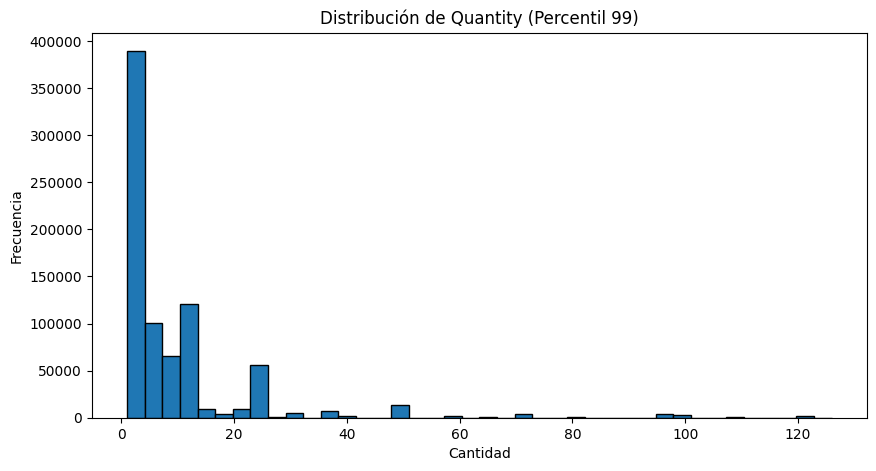

In [39]:
# Percentil 99
p99 = df_clean["Quantity"].quantile(0.99)

plt.figure(figsize=(10,5))

plt.hist(
    df_clean[df_clean["Quantity"] <= p99]["Quantity"],
    bins=40,
    edgecolor="black"
)

plt.title("Distribución de Quantity (Percentil 99)")
plt.xlabel("Cantidad")
plt.ylabel("Frecuencia")

plt.show()

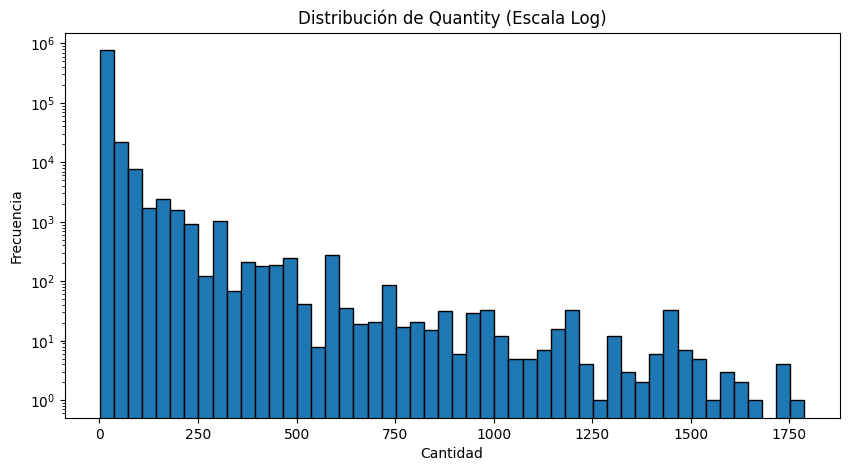

In [40]:
plt.figure(figsize=(10,5))

plt.hist(
    df_clean["Quantity"],
    bins=50,
    log=True,
    edgecolor="black"
)

plt.title("Distribución de Quantity (Escala Log)")
plt.xlabel("Cantidad")
plt.ylabel("Frecuencia")

plt.show()

### Análisis de la variable `Quantity`

La variable **Quantity** representa la cantidad de unidades adquiridas de un producto en cada línea de factura. Su análisis es relevante para los dos modelos de recomendación definidos para el proyecto, aunque su utilización será diferente en cada uno.

Para **FP-Growth**, `Quantity` permite caracterizar el volumen de las compras, pero el modelo se enfocará principalmente en determinar si un producto está presente o no dentro de una factura. Por lo tanto, una compra de 1 unidad y una compra de 20 unidades representan, para la matriz transaccional, la presencia del mismo producto.

Para **Item-Based Collaborative Filtering**, `Quantity` puede utilizarse como una medida de interacción entre el cliente y el producto. Sin embargo, debido a la fuerte dispersión de esta variable, será necesario evaluar posteriormente si se utiliza directamente, se transforma o se convierte en una interacción binaria.

---

#### Estadísticos descriptivos

| Estadístico         | Cantidad |
| ------------------- | -------: |
| Registros           | **805.243** |
| Media               | **12,39** |
| Mediana             | **5,00** |
| Desviación estándar | **37,47** |
| Mínimo              | **1** |
| Percentil 25        | **2** |
| Percentil 75        | **12** |
| Percentil 90        | **24** |
| Percentil 95        | **36** |
| Percentil 99        | **126** |
| Máximo              | **1.788** |

---

#### Interpretación

La **mediana de 5 unidades** indica que al menos el 50 % de las transacciones corresponde a compras de 5 unidades o menos.

El **75 % de las transacciones presenta cantidades de hasta 12 unidades**, mientras que el 90 % no supera las **24 unidades**.

A partir de los percentiles superiores se observa una mayor dispersión:

- El **95 %** de las transacciones registra hasta **36 unidades**.
- El **99 %** registra hasta **126 unidades**.
- El máximo observado después de la limpieza es de **1.788 unidades**.

La diferencia entre la **media (12,39)** y la **mediana (5)** evidencia una distribución fuertemente asimétrica hacia la derecha. Un grupo reducido de transacciones con cantidades elevadas incrementa significativamente el promedio.

---

#### Distribución de la variable

El histograma limitado al **percentil 99** permite visualizar con mayor claridad el comportamiento de la mayoría de las transacciones.

Se observa una alta concentración de operaciones en cantidades relativamente pequeñas y una reducción progresiva de la frecuencia a medida que aumenta la cantidad comprada.

El histograma en **escala logarítmica** permite observar con mayor detalle la cola derecha de la distribución y confirmar la existencia de operaciones de alto volumen.

Esta característica debe tenerse en cuenta al preparar los datos para ambos modelos, ya que una cantidad elevada no necesariamente significa que exista una mayor relación entre un cliente y un producto.

---

#### Tratamiento de valores extremos

Los valores elevados de `Quantity` deben interpretarse con precaución, ya que pueden corresponder a compras de alto volumen realizadas por clientes mayoristas y no necesariamente representan errores de captura.

Como parte del proceso de limpieza se estableció el siguiente criterio:

**Quantity < 1.800 unidades**

Los registros con valores **Quantity ≥ 1.800** fueron considerados valores extremos y eliminados.

Esta decisión permite reducir el impacto de operaciones excepcionalmente grandes sobre el análisis estadístico y evita que unas pocas transacciones tengan una influencia desproporcionada sobre los modelos.

---

## Implicaciones para FP-Growth

Para **FP-Growth**, la cantidad comprada no será utilizada directamente como peso principal de la transacción.

El modelo se construirá a partir de la relación:

```text
Invoice → StockCode
```

Por ejemplo, si una factura contiene:

| Invoice | StockCode | Quantity |
|---|---|---:|
| 489434 | A | 2 |
| 489434 | B | 15 |
| 489434 | C | 1 |

La matriz transaccional representará:

| Invoice | A | B | C |
|---|---:|---:|---:|
| 489434 | 1 | 1 | 1 |

En otras palabras, **FP-Growth estará interesado principalmente en la presencia conjunta de los productos dentro de una cesta**, independientemente de que se hayan comprado 1, 2 o 15 unidades.

Esto evita que los clientes que realizan compras de grandes cantidades tengan una influencia excesiva sobre las reglas de asociación.

---

## Implicaciones para Item-Based Collaborative Filtering

Para **Item-Based Collaborative Filtering**, la variable `Quantity` puede representar una interacción entre un cliente y un producto.

La relación conceptual será:

```text
Customer ID → StockCode → Quantity
```

Por ejemplo:

| Customer ID | StockCode | Quantity |
|---|---|---:|
| 12345 | A | 5 |
| 12345 | B | 2 |
| 12346 | A | 20 |

Esta información puede utilizarse para construir la matriz:

**Cliente × Producto**

Sin embargo, debido a la fuerte asimetría de `Quantity`, utilizar directamente las cantidades puede hacer que los clientes que compran grandes volúmenes tengan un peso excesivo en el cálculo de similitud entre productos.

Por esta razón, durante la etapa de modelado se evaluará una transformación de la interacción, por ejemplo:

```text
Compra = 1
No compra = 0
```

o una transformación/normalización de `Quantity`.

La decisión final deberá basarse en la evaluación del modelo.

---

## Diferencia en el uso de `Quantity`

| Aspecto | FP-Growth | Item-Based CF |
|---|---|---|
| `Quantity` | Variable descriptiva | Posible medida de interacción |
| Unidad principal | Factura | Cliente |
| Estructura | `Invoice → Producto` | `Customer ID → Producto` |
| Uso directo de cantidad | No es necesario | Puede evaluarse |
| Representación principal | Presencia/ausencia | Interacción cliente-producto |
| Riesgo de valores extremos | Puede distorsionar análisis | Puede afectar similitud |
| Tratamiento | Filtrado de extremos | Evaluar binarización/normalización |

---

#### Conclusión

La variable `Quantity` presenta una **distribución fuertemente asimétrica positiva**, con una concentración importante de transacciones en cantidades pequeñas y una cola derecha formada por operaciones de mayor volumen.

La **mediana de 5 unidades**, frente a una media de **12,39 unidades**, confirma que las compras de mayor volumen elevan significativamente el promedio.

El análisis de percentiles muestra que el **99 % de las transacciones se encuentra en cantidades de hasta 126 unidades**, mientras que los valores superiores representan una proporción reducida del conjunto de datos.

El tratamiento de esta variable será diferente para cada modelo. En **FP-Growth**, la cantidad no será el elemento principal para determinar las asociaciones, ya que se trabajará principalmente con la presencia de productos dentro de cada factura. En **Item-Based Collaborative Filtering**, `Quantity` podrá utilizarse como una medida de interacción, pero se deberá evaluar su transformación para evitar que los clientes de alto volumen dominen el cálculo de similitud.

Por lo tanto, el análisis de `Quantity` confirma la necesidad de diferenciar la **frecuencia/presencia de compra** del **volumen comprado**, especialmente durante la preparación de los datos para los dos modelos de recomendación.

# Análisis del Tamaño de la Cesta de Compra (Basket Size)

## Objetivo

El **Basket Size** representa el número de productos diferentes incluidos en una misma factura (Invoice).

Este indicador permite comprender el comportamiento de compra de los clientes y evaluar si el conjunto de datos es adecuado para la aplicación del algoritmo **FP-Growth**, el cual identifica reglas de asociación entre productos comprados conjuntamente.

El análisis responderá preguntas como:

- ¿Cuántos productos compra un cliente en promedio por transacción?
- ¿Cuál es el tamaño promedio de una cesta de compra?
- ¿Existen compras muy grandes que puedan afectar el modelo?
- ¿El dataset contiene suficiente información para descubrir asociaciones entre productos?

In [41]:
# Número de productos diferentes por factura
basket_size = (
    df_clean
    .groupby("Invoice")["StockCode"]
    .nunique()
    .reset_index()
)

basket_size.columns = ["Invoice", "Basket_Size"]

basket_size.head()

,Invoice,Basket_Size
0,489434,8
1,489435,4
2,489436,19
3,489437,23
4,489438,17


In [42]:
basket_size["Basket_Size"].describe()

count    36829.000000
mean        20.868609
std         22.403664
min          1.000000
25%          7.000000
50%         15.000000
75%         27.000000
max        540.000000
Name: Basket_Size, dtype: float64

In [43]:
basket_size["Basket_Size"].describe(
    percentiles=[0.25,0.50,0.75,0.90,0.95,0.99]
)

count    36829.000000
mean        20.868609
std         22.403664
min          1.000000
25%          7.000000
50%         15.000000
75%         27.000000
90%         46.000000
95%         61.000000
99%        101.000000
max        540.000000
Name: Basket_Size, dtype: float64

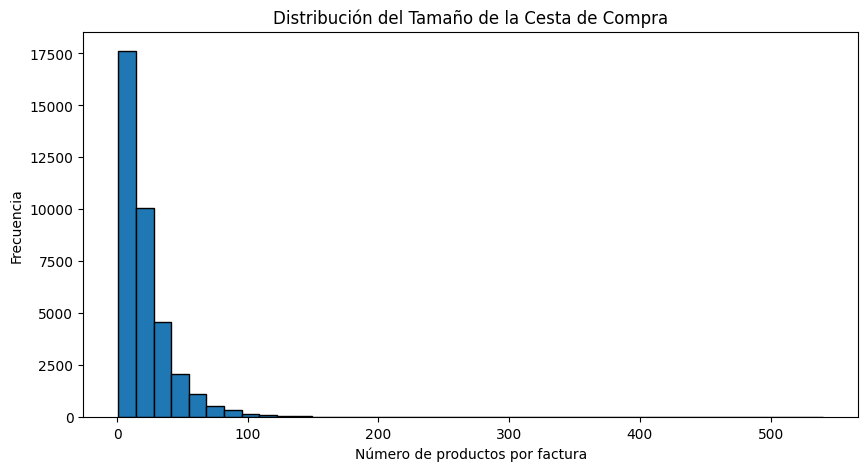

In [44]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.hist(
    basket_size["Basket_Size"],
    bins=40,
    edgecolor="black"
)

plt.title("Distribución del Tamaño de la Cesta de Compra")

plt.xlabel("Número de productos por factura")

plt.ylabel("Frecuencia")

plt.show()

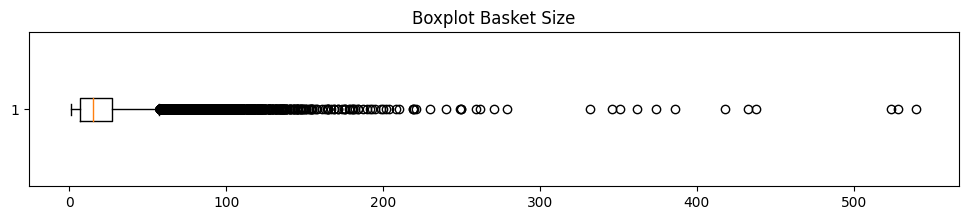

In [45]:
plt.figure(figsize=(12,2))

plt.boxplot(
    basket_size["Basket_Size"],
    vert=False
)

plt.title("Boxplot Basket Size")

plt.show()

In [46]:
print(f"Tamaño promedio de la cesta: {basket_size['Basket_Size'].mean():.2f}")
print(f"Mediana: {basket_size['Basket_Size'].median():.0f}")

Tamaño promedio de la cesta: 20.87
Mediana: 15


In [47]:
basket_size.sort_values(
    "Basket_Size",
    ascending=False
).head(10)

,Invoice,Basket_Size
34539,576339,540
35819,579196,528
36459,580727,524
35424,578270,438
33379,573576,433
30823,567656,418
30635,567183,386
34193,575607,374
32464,571441,362
32908,572552,351


In [48]:
basket_size["Basket_Size"].value_counts().sort_index()

Basket_Size
1      2949
2      1401
3      1246
4      1214
5      1227
       ... 
433       1
438       1
524       1
528       1
540       1
Name: count, Length: 207, dtype: int64

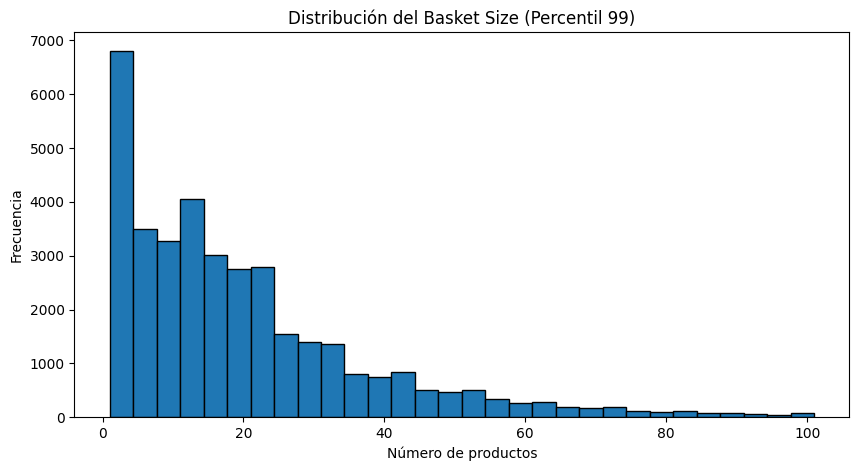

In [49]:
p99 = basket_size["Basket_Size"].quantile(0.99)

plt.figure(figsize=(10,5))

plt.hist(
    basket_size[
        basket_size["Basket_Size"] <= p99
    ]["Basket_Size"],
    bins=30,
    edgecolor="black"
)

plt.title("Distribución del Basket Size (Percentil 99)")

plt.xlabel("Número de productos")

plt.ylabel("Frecuencia")

plt.show()

In [50]:
resumen_basket = pd.DataFrame({
    "Indicador":[
        "Número de facturas",
        "Promedio Basket Size",
        "Mediana",
        "Máximo",
        "Mínimo"
    ],
    "Valor":[
        basket_size.shape[0],
        round(basket_size["Basket_Size"].mean(),2),
        basket_size["Basket_Size"].median(),
        basket_size["Basket_Size"].max(),
        basket_size["Basket_Size"].min()
    ]
})

display(resumen_basket)

,Indicador,Valor
0,Número de facturas,36829.00
1,Promedio Basket Size,20.87
2,Mediana,15.00
3,Máximo,540.00
4,Mínimo,1.00


## Análisis del Tamaño de la Cesta de Compra (Basket Size)

El **Basket Size** representa el número de productos registrados dentro de cada factura y constituye una variable relevante para los dos modelos de recomendación planteados en el proyecto: **FP-Growth** e **Item-Based Collaborative Filtering**.

Para **FP-Growth**, cada factura representa una transacción y los productos que contiene conforman un conjunto de elementos sobre el cual se identifican patrones de compra conjunta.

Para **Item-Based Collaborative Filtering**, el Basket Size permite caracterizar la amplitud de las compras realizadas por los clientes y complementar el análisis de las interacciones entre **CustomerID y productos**. En este modelo, la información de las facturas será posteriormente transformada en una matriz de interacción **cliente–producto**, que permitirá calcular la similitud entre productos.

### Resumen estadístico

| Indicador | Valor |
|---|---:|
| Número de facturas | **36.829** |
| Tamaño promedio de la cesta | **20,87 productos** |
| Mediana | **15 productos** |
| Mínimo | **1 producto** |
| Máximo | **540 productos** |
| Percentil 90 | **46 productos** |
| Percentil 95 | **61 productos** |
| Percentil 99 | **101 productos** |

### Interpretación de los resultados

El conjunto de datos contiene **36.829 facturas**, que constituyen las unidades de transacción utilizadas para el análisis de comportamiento de compra.

El **tamaño promedio de la cesta es de 20,87 productos**, mientras que la **mediana es de 15 productos**. La diferencia entre ambos valores evidencia una **distribución asimétrica positiva**, ocasionada principalmente por la existencia de un grupo reducido de facturas con una cantidad considerablemente mayor de productos.

La distribución muestra que:

- El **50 % de las facturas contiene hasta 15 productos**.
- El **75 % contiene hasta 27 productos**.
- El **90 % contiene hasta 46 productos**.
- El **95 % contiene hasta 61 productos**.
- El **99 % contiene hasta 101 productos**.

Por lo tanto, aproximadamente el **99 % de las facturas se encuentra dentro de una cesta de hasta 101 productos**, mientras que solamente una proporción reducida presenta tamaños superiores.

El valor máximo observado es de **540 productos por factura**, confirmando la existencia de transacciones excepcionalmente grandes.

### Distribución del Basket Size

El histograma evidencia una elevada concentración de las facturas en tamaños de cesta relativamente pequeños y una disminución progresiva de la frecuencia a medida que aumenta el número de productos.

La forma de la distribución confirma una **cola derecha prolongada**. Esto significa que la mayoría de las transacciones se concentra en tamaños relativamente bajos, mientras que existe un grupo reducido de compras de gran volumen.

El análisis mediante el **percentil 99** permite visualizar con mayor claridad el comportamiento de la mayoría de las transacciones, evitando que las facturas extremadamente grandes dominen la escala del gráfico.

El **boxplot** confirma igualmente la presencia de numerosos valores extremos por encima del rango habitual de las cestas. Sin embargo, estos valores no deben interpretarse automáticamente como errores.

### Cestas pequeñas y grandes

Las primeras posiciones de la distribución muestran una cantidad importante de facturas con pocos productos. En particular, existen **2.949 facturas con un Basket Size de 1**, seguidas por **1.401 facturas con 2 productos** y **1.246 facturas con 3 productos**.

Las cestas de un solo producto tienen una característica importante para el modelo **FP-Growth**: no permiten generar asociaciones entre diferentes productos dentro de la misma transacción.

A medida que aumenta el tamaño de la cesta, aumenta también la cantidad potencial de combinaciones entre productos.

Por ejemplo:

- Una cesta con **2 productos** permite identificar una asociación entre ambos.
- Una cesta con **3 productos** permite identificar diferentes combinaciones de pares y una combinación de tres productos.
- Una cesta con mayor cantidad de productos proporciona una mayor cantidad de información para descubrir patrones de compra conjunta.

Por esta razón, las transacciones con múltiples productos son especialmente importantes para **FP-Growth**.

## Implicaciones para FP-Growth

Los resultados muestran condiciones favorables para la construcción del modelo de **FP-Growth**.

Las **36.829 facturas** serán transformadas en transacciones de la siguiente forma:

```text
Invoice → [Producto 1, Producto 2, Producto 3, ...]

# 6. Análisis Bivariado

## Objetivo

El análisis bivariado tiene como propósito estudiar la relación entre dos variables del conjunto de datos para identificar patrones de compra relevantes que permitan comprender el comportamiento de los clientes y los productos.

En esta etapa se analizarán las relaciones entre:

- País y ventas.
- Productos y cantidad vendida.
- Productos e ingresos.
- Clientes y frecuencia de compra.
- Clientes y gasto total.
- Facturas y número de productos.
- Productos comprados conjuntamente.

Los resultados obtenidos servirán como base para la construcción del sistema de recomendación mediante.

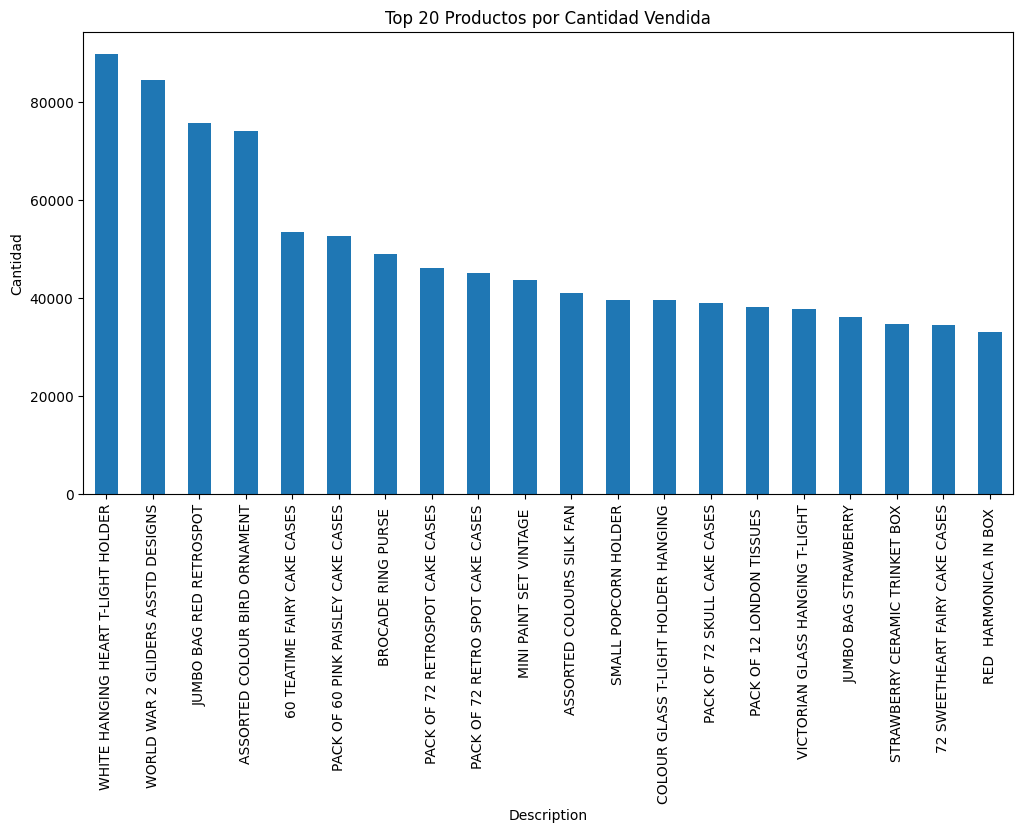

In [51]:
# Top 20 Productos más vendidos

top_productos = (
    df_clean
    .groupby("Description")["Quantity"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

plt.figure(figsize=(12,6))

top_productos.plot(kind="bar")

plt.title("Top 20 Productos por Cantidad Vendida")

plt.ylabel("Cantidad")

plt.show()

In [52]:
df_clean["Total"] = df_clean["Quantity"] * df_clean["Price"]

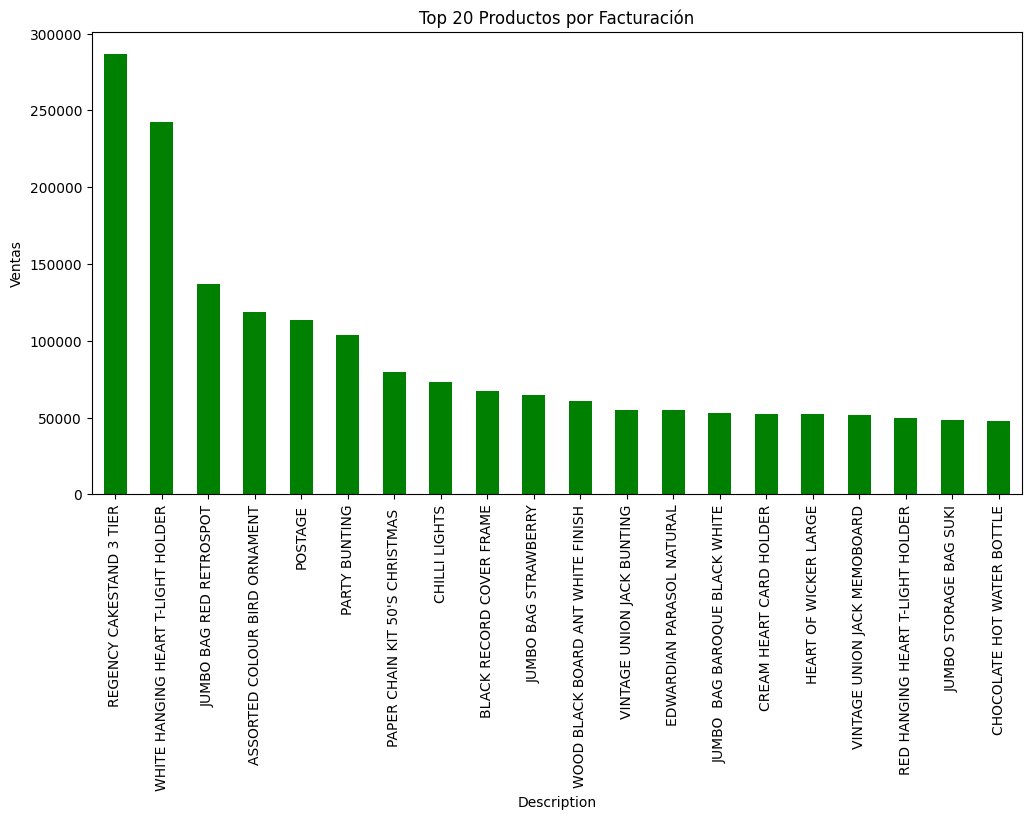

In [53]:
# Productos con mayor facturación
ventas_producto = (
    df_clean
    .groupby("Description")["Total"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

plt.figure(figsize=(12,6))

ventas_producto.plot(kind="bar", color="green")

plt.title("Top 20 Productos por Facturación")

plt.ylabel("Ventas")

plt.show()

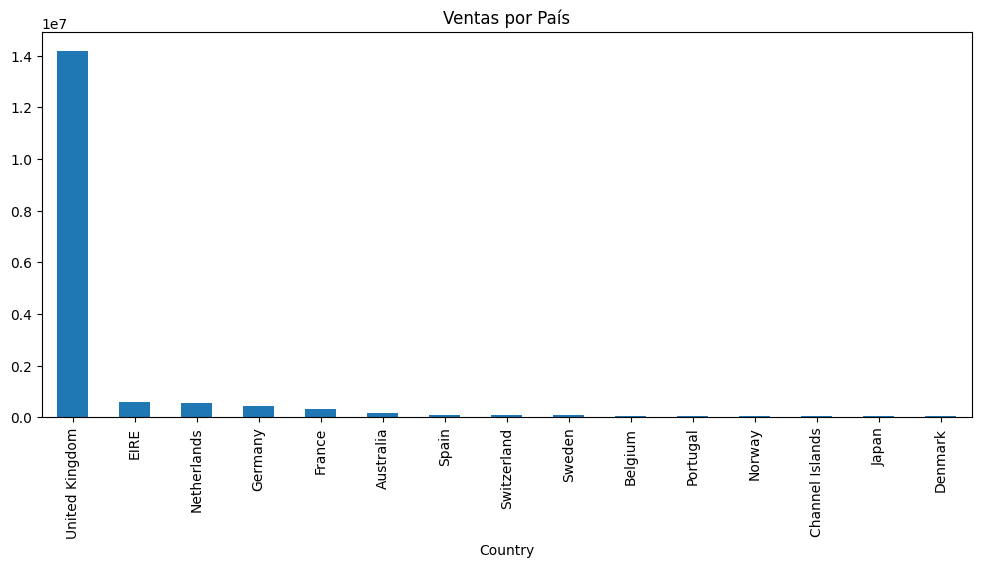

In [54]:
# Países con mayor facturación
ventas_pais = (
    df_clean
    .groupby("Country")["Total"]
    .sum()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12,5))

ventas_pais.plot(kind="bar")

plt.title("Ventas por País")

plt.show()

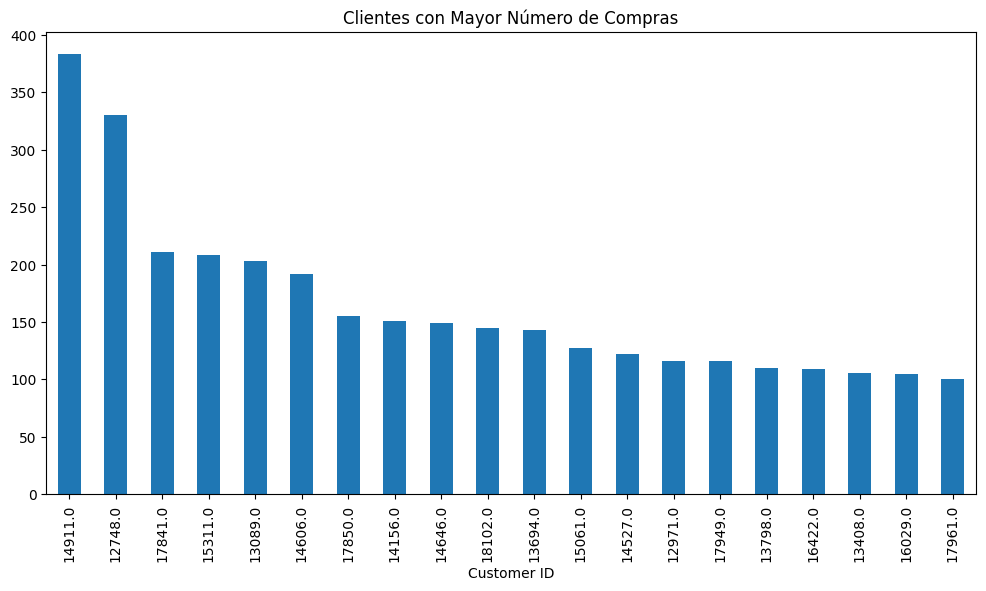

In [55]:
# Clientes con mayor frecuencia

clientes_frecuencia = (
    df_clean
    .groupby("Customer ID")["Invoice"]
    .nunique()
    .sort_values(ascending=False)
    .head(20)
)

plt.figure(figsize=(12,6))

clientes_frecuencia.plot(kind="bar")

plt.title("Clientes con Mayor Número de Compras")

plt.show()

In [56]:
# Clientes con mayor frecuencia

# matriz de transacciones.

basket = (
    df_clean
    .groupby(["Invoice","Description"])["Quantity"]
    .sum()
    .unstack()
    .fillna(0)
)

In [57]:
df = df.map(lambda x: x.strip() if isinstance(x, str) else x)

In [58]:
productos = basket.sum().sort_values(ascending=False).head(20)

productos

Description
WHITE HANGING HEART T-LIGHT HOLDER     89780.0
WORLD WAR 2 GLIDERS ASSTD DESIGNS      84497.0
JUMBO BAG RED RETROSPOT                75759.0
ASSORTED COLOUR BIRD ORNAMENT          74153.0
60 TEATIME FAIRY CAKE CASES            53495.0
PACK OF 60 PINK PAISLEY CAKE CASES     52570.0
BROCADE RING PURSE                     48953.0
PACK OF 72 RETROSPOT CAKE CASES        46107.0
PACK OF 72 RETRO SPOT CAKE CASES       45156.0
MINI PAINT SET VINTAGE                 43621.0
ASSORTED COLOURS SILK FAN              41078.0
SMALL POPCORN HOLDER                   39670.0
COLOUR GLASS T-LIGHT HOLDER HANGING    39643.0
PACK OF 72 SKULL CAKE CASES            38927.0
PACK OF 12 LONDON TISSUES              38084.0
VICTORIAN GLASS HANGING T-LIGHT        37851.0
JUMBO BAG STRAWBERRY                   36098.0
STRAWBERRY CERAMIC TRINKET BOX         34726.0
72 SWEETHEART FAIRY CAKE CASES         34541.0
RED  HARMONICA IN BOX                  33037.0
dtype: float64

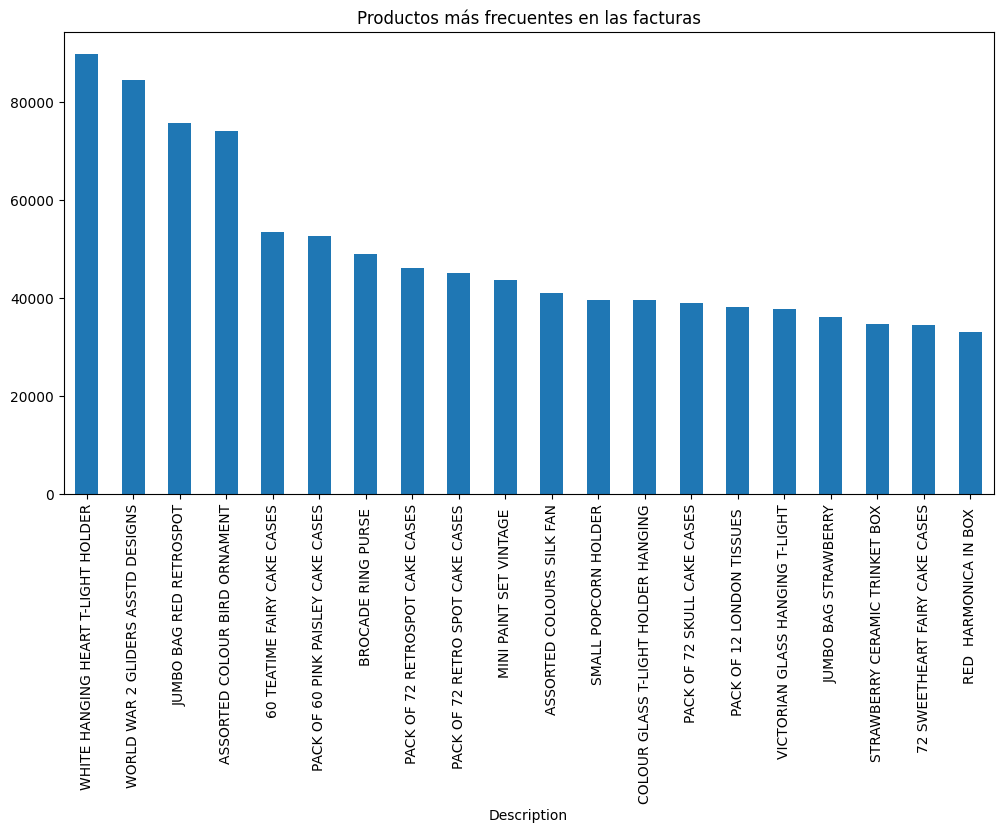

In [59]:
plt.figure(figsize=(12,6))

productos.plot(kind="bar")

plt.title("Productos más frecuentes en las facturas")

plt.show()

In [60]:
# Productos más vendidos
top20 = basket.sum().sort_values(ascending=False).head(20).index

In [61]:
import numpy as np

coocurrencia = basket[top20].T.dot(basket[top20])

matriz = coocurrencia.to_numpy(copy=True)

np.fill_diagonal(matriz, 0)

coocurrencia = pd.DataFrame(
    matriz,
    index=coocurrencia.index,
    columns=coocurrencia.columns
)

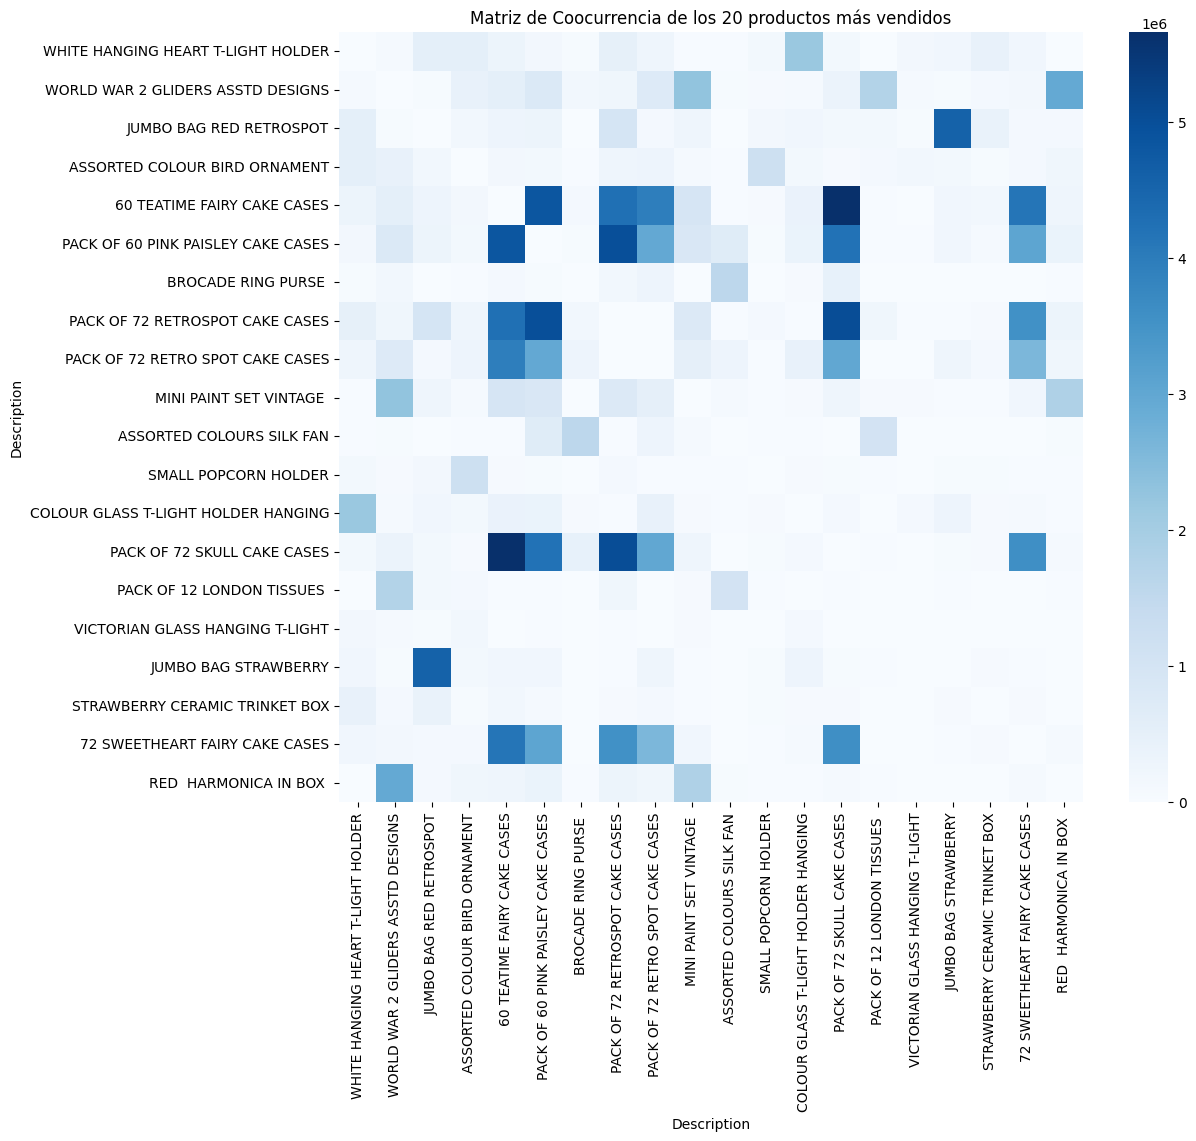

In [62]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,10))

sns.heatmap(
    coocurrencia,
    cmap="Blues",
    annot=False
)

plt.title("Matriz de Coocurrencia de los 20 productos más vendidos")
plt.show()

# Conclusiones del Análisis Bivariado

El análisis bivariado permitió estudiar las relaciones entre **productos, clientes y mercados**, identificando patrones relevantes para el desarrollo de los dos enfoques de recomendación planteados en el proyecto:

- **FP-Growth:** basado en reglas de asociación entre productos comprados conjuntamente.
- **Item-Based Collaborative Filtering:** basado en la similitud entre productos a partir de los patrones de interacción de los clientes.

Los resultados muestran una concentración importante de la demanda en determinados productos, la existencia de clientes altamente recurrentes, un mercado principal claramente identificado y relaciones de coocurrencia entre productos.

Estos hallazgos proporcionan evidencia favorable para utilizar el dataset limpio como fuente común para ambos modelos, aunque cada algoritmo utilizará la información desde una perspectiva diferente.

---

## Productos con mayor cantidad vendida

El análisis de las unidades vendidas evidencia una concentración de la demanda en un grupo reducido de productos.

Los productos con mayor cantidad vendida son:

1. **WHITE HANGING HEART T-LIGHT HOLDER**
2. **WORLD WAR 2 GLIDERS ASSTD DESIGNS**
3. **JUMBO BAG RED RETROSPOT**
4. **ASSORTED COLOUR BIRD ORNAMENT**
5. **60 TEATIME FAIRY CAKE CASES**
6. **PACK OF 60 PINK PAISLEY CAKE CASES**
7. **BROCADE RING PURSE**
8. **PACK OF 72 RETROSPOT CAKE CASES**
9. **PACK OF 72 RETRO SPOT CAKE CASES**
10. **MINI PAINT SET VINTAGE**

El producto con mayor volumen es **WHITE HANGING HEART T-LIGHT HOLDER**, con aproximadamente **89.800 unidades**, seguido por **WORLD WAR 2 GLIDERS ASSTD DESIGNS**, con aproximadamente **84.500 unidades**.

Este comportamiento evidencia que algunos productos presentan una alta rotación y aparecen de manera recurrente dentro de las transacciones.

### Implicaciones para FP-Growth

Desde la perspectiva de **FP-Growth**, estos productos tienen una mayor probabilidad de alcanzar valores elevados de **Support**, debido a su alta frecuencia de aparición en las transacciones.

Sin embargo, una alta frecuencia individual no significa necesariamente que exista una asociación fuerte con otros productos. Por esta razón, será necesario evaluar posteriormente las métricas de:

- **Support**
- **Confidence**
- **Lift**

### Implicaciones para Item-Based Collaborative Filtering

Para **Item-Based Collaborative Filtering**, los productos con mayor frecuencia representan ítems con un elevado número de interacciones dentro del dataset.

Estos productos pueden convertirse en productos de referencia para calcular similitudes con otros artículos. Sin embargo, su elevada popularidad debe considerarse durante la evaluación, ya que un producto muy popular puede presentar muchas interacciones sin necesariamente ser el producto más similar a otro.

---

## Productos con mayor facturación

El ranking por facturación presenta diferencias importantes respecto al ranking por cantidad vendida.

Los productos con mayor facturación son:

1. **REGENCY CAKESTAND 3 TIER**
2. **WHITE HANGING HEART T-LIGHT HOLDER**
3. **JUMBO BAG RED RETROSPOT**
4. **ASSORTED COLOUR BIRD ORNAMENT**
5. **POSTAGE**
6. **PARTY BUNTING**
7. **PAPER CHAIN KIT 50'S CHRISTMAS**
8. **CHILLI LIGHTS**
9. **BLACK RECORD COVER FRAME**
10. **JUMBO BAG STRAWBERRY**

El producto **REGENCY CAKESTAND 3 TIER** ocupa el primer lugar en facturación, aunque no aparece entre los primeros productos por cantidad vendida.

Este resultado demuestra que **volumen de unidades y facturación son dimensiones diferentes del desempeño comercial**.

Un producto puede vender menos unidades y generar mayores ingresos debido a su precio unitario.

### Implicaciones para los modelos

Esta diferencia es relevante para el sistema de recomendación porque permite identificar dos tipos de productos:

- Productos de **alta rotación**.
- Productos de **alto valor comercial**.

En **FP-Growth**, esta información puede utilizarse posteriormente como variable complementaria para priorizar reglas de asociación con mayor potencial comercial.

En **Item-Based Collaborative Filtering**, la facturación puede utilizarse como información adicional para construir estrategias de ranking de recomendaciones, aunque la similitud entre productos se calculará principalmente a partir de las interacciones cliente-producto.

---

## Comparación entre cantidad vendida y facturación

La comparación de ambos rankings permite identificar diferentes comportamientos comerciales.

### Productos de alta rotación

Son productos que presentan un elevado volumen de unidades vendidas y una alta frecuencia dentro de las facturas.

Ejemplos:

- **WHITE HANGING HEART T-LIGHT HOLDER**
- **JUMBO BAG RED RETROSPOT**
- **ASSORTED COLOUR BIRD ORNAMENT**

Estos productos representan artículos de alta demanda y pueden actuar como productos de referencia para generar recomendaciones.

### Productos de alto valor comercial

El caso más representativo es:

- **REGENCY CAKESTAND 3 TIER**

Este producto presenta una facturación muy superior a su posición relativa en cantidad vendida.

Esto demuestra que las recomendaciones pueden generar valor no solamente aumentando el número de productos vendidos, sino también orientando al cliente hacia productos de mayor valor.

### Productos frecuentes de bajo o medio valor

Otros artículos presentan elevada frecuencia y cantidad vendida, pero no necesariamente lideran la facturación.

Estos productos pueden funcionar como **productos de entrada** para generar recomendaciones complementarias.

---

## Ventas por país

El análisis geográfico evidencia una fuerte concentración de las ventas en **United Kingdom**.

El Reino Unido presenta una diferencia considerable respecto al resto de países, seguido por mercados como:

- **EIRE**
- **Netherlands**
- **Germany**
- **France**
- **Australia**
- **Spain**
- **Switzerland**

Esta concentración indica que el comportamiento general del dataset está fuertemente determinado por el mercado británico.

### Implicaciones para FP-Growth

Las reglas de asociación generadas por **FP-Growth** estarán principalmente influenciadas por los patrones de compra observados en **United Kingdom**.

Esto debe considerarse durante la interpretación de las reglas, especialmente si posteriormente se desea generar recomendaciones específicas por país.

### Implicaciones para Item-Based Collaborative Filtering

En **Item-Based Collaborative Filtering**, la concentración geográfica también puede influir en las interacciones entre clientes y productos.

Por ejemplo, si determinados productos son comprados principalmente por clientes del Reino Unido, las similitudes calculadas entre estos productos estarán fuertemente influenciadas por ese mercado.

Por esta razón, el país puede utilizarse posteriormente como variable de segmentación o filtro en el sistema de recomendación.

---

## Clientes con mayor número de compras

El análisis de frecuencia de compra muestra la existencia de clientes altamente recurrentes.

El cliente **14911** registra aproximadamente **400 compras**, seguido por el cliente **12748**, con más de **330 transacciones**.

También se observa un grupo adicional de clientes con más de 150 o 200 compras.

Esto evidencia una distribución concentrada de la actividad comercial, donde determinados clientes realizan muchas más transacciones que el cliente promedio.

Este comportamiento es consistente con la presencia de clientes mayoristas mencionada en la descripción del dataset.

### Implicaciones para Item-Based Collaborative Filtering

Este hallazgo es especialmente importante para **Item-Based Collaborative Filtering**, debido a que este modelo necesita las interacciones entre **clientes y productos** para calcular la similitud entre ítems.

Conceptualmente, el dataset será transformado en una matriz:

```text
                 Producto A   Producto B   Producto C   Producto D
Customer 1             1            1            0            1
Customer 2             0            1            1            0
Customer 3             1            0            1            1
Customer 4             0            1            0            1

# 7. Análisis Temporal

## Objetivo

El análisis temporal tiene como propósito estudiar la evolución de las ventas durante el período comprendido entre diciembre de 2009 y diciembre de 2011.

Este análisis permitirá identificar tendencias, estacionalidades y patrones de compra a lo largo del tiempo, respondiendo preguntas como:

- ¿Cómo evolucionan las ventas durante el período de estudio?
- ¿Existen meses con mayor actividad comercial?
- ¿Qué días de la semana presentan mayor volumen de ventas?
- ¿En qué horas del día se realizan más compras?
- ¿Se observan patrones estacionales que puedan influir en las recomendaciones de productos?

La información obtenida complementará el análisis exploratorio y permitirá comprender mejor el comportamiento de las transacciones antes de construir el modelo de recomendaciones basado en **FP-Growth**.

In [63]:
# Convertir la fecha a tipo datetime
df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"])

# Variables temporales
df_clean["Año"] = df_clean["InvoiceDate"].dt.year
df_clean["Mes"] = df_clean["InvoiceDate"].dt.month
df_clean["Nombre_Mes"] = df_clean["InvoiceDate"].dt.month_name()
df_clean["Dia"] = df_clean["InvoiceDate"].dt.day
df_clean["Dia_Semana"] = df_clean["InvoiceDate"].dt.day_name()
df_clean["Hora"] = df_clean["InvoiceDate"].dt.hour

# Valor de la venta
df_clean["Total"] = df_clean["Quantity"] * df_clean["Price"]

In [64]:
# Evolución mensual de las ventas

ventas_mes = (
    df_clean
    .groupby(pd.Grouper(key="InvoiceDate", freq="ME"))["Total"]
    .sum()
)

plt.figure(figsize=(14,6))

ventas_mes.plot(marker="o")

plt.title("Evolución Mensual de las Ventas")

plt.ylabel("Ventas")

plt.grid(True)

plt.show()

ValueError: Invalid frequency: ME

In [ ]:
# Ventas por año

ventas_anio = (
    df_clean
    .groupby("Año")["Total"]
    .sum()
)

plt.figure(figsize=(7,5))

ventas_anio.plot(kind="bar")

plt.title("Ventas por Año")

plt.ylabel("Ventas")

plt.show()

In [ ]:
# Ventas  por Mes
orden_meses = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

ventas_mes_nombre = (
    df_clean
    .groupby("Nombre_Mes")["Total"]
    .sum()
    .reindex(orden_meses)
)

plt.figure(figsize=(12,5))

ventas_mes_nombre.plot(kind="bar")

plt.title("Ventas por Mes")

plt.ylabel("Ventas")

plt.show()

In [ ]:
facturas_mes = (
    df_clean
    .groupby("Nombre_Mes")["Invoice"]
    .nunique()
    .reindex(orden_meses)
)

plt.figure(figsize=(12,5))

facturas_mes.plot(kind="bar", color="orange")

plt.title("Número de Facturas por Mes")

plt.ylabel("Facturas")

plt.show()

In [ ]:
orden_dias = [
    "Monday","Tuesday","Wednesday",
    "Thursday","Friday","Saturday","Sunday"
]

ventas_dia = (
    df_clean
    .groupby("Dia_Semana")["Total"]
    .sum()
    .reindex(orden_dias)
)

plt.figure(figsize=(10,5))

ventas_dia.plot(kind="bar")

plt.title("Ventas por Día de la Semana")

plt.ylabel("Ventas")

plt.show()

In [ ]:
facturas_dia = (
    df_clean
    .groupby("Dia_Semana")["Invoice"]
    .nunique()
    .reindex(orden_dias)
)

plt.figure(figsize=(10,5))

facturas_dia.plot(kind="bar", color="green")

plt.title("Facturas por Día de la Semana")

plt.ylabel("Cantidad")

plt.show()

In [ ]:
ventas_hora = (
    df_clean
    .groupby("Hora")["Total"]
    .sum()
)

plt.figure(figsize=(12,5))

ventas_hora.plot(marker="o")

plt.title("Ventas por Hora del Día")

plt.xlabel("Hora")

plt.ylabel("Ventas")

plt.grid(True)

plt.show()

In [ ]:
facturas_hora = (
    df_clean
    .groupby("Hora")["Invoice"]
    .nunique()
)

plt.figure(figsize=(12,5))

facturas_hora.plot(marker="o", color="red")

plt.title("Número de Facturas por Hora")

plt.xlabel("Hora")

plt.ylabel("Facturas")

plt.grid(True)

plt.show()

In [ ]:
import seaborn as sns

heat = df_clean.pivot_table(
    values="Total",
    index="Dia_Semana",
    columns="Hora",
    aggfunc="sum"
)

heat = heat.reindex(orden_dias)

plt.figure(figsize=(15,6))

sns.heatmap(
    heat,
    cmap="YlGnBu"
)

plt.title("Mapa de Calor de Ventas")

plt.show()

In [ ]:
resumen_temporal = pd.DataFrame({
    "Indicador":[
        "Periodo analizado",
        "Número de años",
        "Número de meses",
        "Primer registro",
        "Último registro"
    ],
    "Valor":[
        f"{df_clean['InvoiceDate'].min().date()} - {df_clean['InvoiceDate'].max().date()}",
        df_clean["Año"].nunique(),
        df_clean["Nombre_Mes"].nunique(),
        df_clean["InvoiceDate"].min(),
        df_clean["InvoiceDate"].max()
    ]
})

display(resumen_temporal)

# Conclusiones del Análisis Temporal

El análisis temporal permitió comprender la evolución de las ventas y de las transacciones durante el período comprendido entre **diciembre de 2009 y diciembre de 2011**, identificando patrones de estacionalidad, períodos de mayor actividad comercial, días de mayor demanda y horarios con mayor concentración de compras.

El análisis es relevante para los dos modelos de recomendación planteados:

- **FP-Growth:** permite identificar patrones de compra conjunta que pueden variar según la temporada o período del año.
- **Item-Based Collaborative Filtering:** permite analizar la evolución temporal de las interacciones entre clientes y productos y considerar la recencia de dichas interacciones para generar recomendaciones.

---

## 1. Período analizado

El conjunto de datos comprende información desde:

- **Primer registro:** 2009-12-01 07:45:00
- **Último registro:** 2011-12-09 12:50:00
- **Período:** diciembre de 2009 a diciembre de 2011
- **Número de años:** 3 años calendario
- **Número de meses:** 12 meses del año

Es importante considerar que **2009 contiene únicamente información correspondiente a diciembre**, mientras que **diciembre de 2011 está incompleto**, ya que el último registro corresponde al 9 de diciembre.

Por esta razón, las comparaciones anuales y mensuales deben interpretarse considerando la cobertura desigual de estos dos períodos.

---

## 2. Evolución mensual de las ventas

La evolución mensual muestra variaciones importantes a lo largo del período analizado.

Durante 2010 se observa un crecimiento significativo de las ventas a partir de septiembre, alcanzando los mayores niveles durante **octubre y noviembre**.

En 2011 se observa nuevamente un incremento importante durante el último trimestre, alcanzando un máximo en **noviembre**.

Este comportamiento evidencia una **estacionalidad comercial**, caracterizada por un incremento de la actividad durante los últimos meses del año.

El comportamiento observado es consistente con un negocio retail en el que las compras pueden incrementarse durante períodos asociados a campañas comerciales y temporada navideña.

La caída observada en diciembre de 2011 no debe interpretarse como una disminución real de la demanda, debido a que el dataset solamente contiene información hasta el **9 de diciembre de 2011**.

---

## 3. Ventas por año

El análisis anual muestra tres períodos:

- **2009:** presenta un volumen reducido debido a que solamente contiene información de diciembre.
- **2010:** registra aproximadamente **8,5 millones** en ventas y representa el año con mayor volumen dentro del período completo.
- **2011:** registra aproximadamente **7,9 millones**, aunque el año no se encuentra completo.

Por lo tanto, la diferencia entre 2010 y 2011 debe interpretarse con precaución, ya que **2011 no contiene todo el mes de diciembre**.

El comportamiento general de 2010 y 2011 permite observar que existe una actividad comercial significativa y relativamente estable, acompañada por un incremento importante durante el último trimestre.

---

## 4. Ventas por mes

Al consolidar las ventas por mes del año se observa una marcada estacionalidad.

Los meses con mayor volumen de ventas son:

1. **Noviembre**
2. **Octubre**
3. **Septiembre**
4. **Diciembre**

Por el contrario, **febrero, enero y abril** presentan niveles relativamente inferiores.

El mes de **noviembre** presenta el mayor volumen acumulado de ventas, superando los **2,2 millones** aproximadamente en la agregación mostrada.

Este comportamiento confirma que el último trimestre concentra una parte importante de la actividad comercial.

---

## 5. Número de facturas por mes

El comportamiento del número de facturas es consistente con la evolución de las ventas.

Los mayores volúmenes de facturas se presentan durante:

- **Noviembre**
- **Octubre**
- **Diciembre**
- **Septiembre**

Noviembre registra aproximadamente **5.200 facturas**, siendo el mes con mayor cantidad de transacciones.

Este resultado indica que el incremento de las ventas durante el último trimestre no solamente está relacionado con compras de mayor valor, sino también con un aumento en el número de transacciones.

Por lo tanto, existe evidencia de una mayor actividad comercial durante este período.

---

## 6. Ventas por día de la semana

El análisis por día de la semana muestra diferencias importantes en el comportamiento de las ventas.

Los días con mayor volumen de ventas son:

1. **Thursday**
2. **Tuesday**
3. **Wednesday**
4. **Monday**
5. **Friday**
6. **Sunday**
7. **Saturday**

El **jueves** presenta el mayor volumen de ventas, mientras que el **sábado** prácticamente no registra actividad comercial.

El domingo también presenta un nivel de ventas considerablemente inferior al observado durante los principales días laborales.

Este comportamiento indica que la actividad comercial se concentra principalmente durante los días de semana.

---

## 7. Número de facturas por día de la semana

El número de facturas presenta un comportamiento similar al observado en las ventas.

El **jueves** registra el mayor número de transacciones, seguido por:

- Miércoles
- Martes
- Lunes
- Viernes

Los fines de semana presentan una actividad considerablemente menor, especialmente el sábado.

La similitud entre la distribución de ventas y la distribución de facturas indica que los días de mayor facturación también concentran un mayor número de transacciones.

---

## 8. Ventas por hora

El comportamiento horario muestra una concentración muy marcada de la actividad comercial.

Las ventas comienzan aproximadamente a las **06:00**, aumentan progresivamente durante la mañana y alcanzan su máximo alrededor de las **12:00 horas**.

El punto máximo de ventas se encuentra aproximadamente al mediodía, superando los **2,6 millones** en el acumulado mostrado.

Después de las 12:00 horas se observa una disminución progresiva de las ventas hasta las últimas horas de actividad.

Por lo tanto, la franja comprendida aproximadamente entre **10:00 y 15:00 horas** representa el período de mayor actividad comercial.

---

## 9. Número de facturas por hora

El número de facturas presenta prácticamente el mismo comportamiento observado en las ventas.

La cantidad de transacciones aumenta durante la mañana y alcanza su máximo alrededor de las **12:00 horas**, con más de **6.000 facturas** aproximadamente.

Después del mediodía comienza una reducción progresiva de la actividad.

La coincidencia entre el comportamiento de ventas y número de facturas indica que el pico de ventas está relacionado principalmente con una mayor cantidad de transacciones y no exclusivamente con operaciones individuales de mayor valor.

---

## 10. Mapa de calor de ventas

El mapa de calor permite integrar las variables **día de la semana y hora**, facilitando la identificación de las franjas de mayor actividad.

Se observa una concentración importante de ventas durante:

- **Martes**
- **Miércoles**
- **Jueves**
- Entre aproximadamente **10:00 y 15:00 horas**

El mayor nivel de actividad se concentra alrededor del **mediodía**, especialmente durante los días centrales de la semana.

Por el contrario, el sábado presenta una actividad prácticamente nula y las primeras horas de la mañana presentan niveles de ventas considerablemente inferiores.

Este resultado permite identificar ventanas temporales de alta actividad comercial que pueden utilizarse como información complementaria para el sistema de recomendación.

---

# Implicaciones para FP-Growth

El modelo **FP-Growth** utiliza las transacciones para identificar conjuntos frecuentes de productos y posteriormente generar reglas de asociación.

El análisis temporal muestra que los patrones de compra no necesariamente son constantes durante todo el año.

La marcada concentración de ventas durante **septiembre, octubre y noviembre** sugiere que determinados productos y asociaciones pueden presentar una mayor frecuencia durante períodos específicos.

Por esta razón, una futura evolución del modelo podría generar reglas diferenciadas por período:

```text
Período → Transacciones → FP-Growth → Reglas de asociación

# 8. Análisis de Clientes

## Objetivo

El análisis de clientes tiene como propósito comprender el comportamiento de compra de los consumidores a partir de su historial de transacciones.

Este análisis permite conocer la estructura de la base de clientes, identificar compradores frecuentes y reconocer aquellos que generan un mayor valor para el negocio.

En esta sección se responderán las siguientes preguntas:

- ¿Cuántos clientes únicos existen?
- ¿Quiénes realizan el mayor número de compras?
- ¿Quiénes generan mayores ingresos?
- ¿Cuál es el gasto promedio por cliente?
- ¿Cómo se distribuye la frecuencia de compra?
- ¿Existen clientes con comportamientos atípicos?

In [ ]:
# Número de clientes
clientes = df_clean["Customer ID"].nunique()

print(f"Número de clientes únicos: {clientes:,}")

In [ ]:
# Clientes con mayor número de compras

clientes_compras = (
    df_clean
    .groupby("Customer ID")["Invoice"]
    .nunique()
    .sort_values(ascending=False)
)

clientes_compras.head(20)

In [ ]:
plt.figure(figsize=(12,6))

clientes_compras.head(20).plot(kind="bar")

plt.title("Top 20 Clientes por Número de Compras")

plt.xlabel("Customer ID")

plt.ylabel("Número de Facturas")

plt.show()

In [ ]:
# Clientes con mayor facturación

clientes_ventas = (
    df_clean
    .groupby("Customer ID")["Total"]
    .sum()
    .sort_values(ascending=False)
)

clientes_ventas.head(20)

In [ ]:
plt.figure(figsize=(12,6))

clientes_ventas.head(20).plot(kind="bar", color="green")

plt.title("Top 20 Clientes por Facturación")

plt.ylabel("Ventas")

plt.show()

In [ ]:
# Distribución del gasto por cliente

ventas_cliente = (
    df_clean
    .groupby("Customer ID")["Total"]
    .sum()
)

In [ ]:
plt.figure(figsize=(10,5))

plt.hist(
    ventas_cliente,
    bins=50,
    edgecolor="black"
)

plt.title("Distribución del Gasto por Cliente")

plt.xlabel("Ventas")

plt.ylabel("Número de Clientes")

plt.show()

In [ ]:
# Distribución de la frecuencia de compra

frecuencia_cliente = (
    df_clean
    .groupby("Customer ID")["Invoice"]
    .nunique()
)

In [ ]:
plt.figure(figsize=(10,5))

plt.hist(
    frecuencia_cliente,
    bins=40,
    edgecolor="black"
)

plt.title("Distribución de la Frecuencia de Compra")

plt.xlabel("Número de Compras")

plt.ylabel("Clientes")

plt.show()

In [ ]:
# Ticket promedio por cliente
ticket_cliente = (
    df_clean
    .groupby("Customer ID")
    .agg({
        "Total":"sum",
        "Invoice":"nunique"
    })
)

ticket_cliente["Ticket_Promedio"] = (
    ticket_cliente["Total"] /
    ticket_cliente["Invoice"]
)

ticket_cliente.head()

In [ ]:
ticket_cliente["Ticket_Promedio"].describe()

In [ ]:
# Top clientes por ticket promedio
ticket_cliente.sort_values(
    "Ticket_Promedio",
    ascending=False
).head(20)

In [ ]:
resumen_clientes = pd.DataFrame({

"Indicador":[

"Clientes únicos",

"Ventas promedio por cliente",

"Compras promedio por cliente",

"Ticket promedio"

],

"Valor":[

df_clean["Customer ID"].nunique(),

round(ventas_cliente.mean(),2),

round(frecuencia_cliente.mean(),2),

round(ticket_cliente["Ticket_Promedio"].mean(),2)

]

})

display(resumen_clientes)

In [ ]:
plt.figure(figsize=(12,2))

plt.boxplot(
    ventas_cliente,
    vert=False
)

plt.title("Distribución del Gasto por Cliente")

plt.show()

In [ ]:
plt.figure(figsize=(12,2))

plt.boxplot(
    frecuencia_cliente,
    vert=False
)

plt.title("Frecuencia de Compra")

plt.show()

# Conclusiones del Análisis de Clientes

El análisis de clientes permitió caracterizar el comportamiento de compra y establecer las condiciones necesarias para desarrollar los dos modelos de recomendación planteados: **FP-Growth** e **Item-Based Collaborative Filtering**.

Durante el período analizado se identificaron **5.868 clientes únicos**, con un promedio de **6,28 compras por cliente**, aproximadamente **291.110 unidades monetarias de ventas promedio agregadas por cliente** y un **ticket promedio de 365,20** por factura.

| Indicador | Valor |
|---|---:|
| Clientes únicos | **5.868** |
| Ventas promedio por cliente | **291.110** |
| Compras promedio por cliente | **6,28** |
| Ticket promedio | **365,20** |

> **Nota:** Los valores corresponden a los resultados obtenidos en el análisis presentado.

---

## 1. Tamaño de la base de clientes

El dataset contiene **5.868 clientes únicos**, lo que representa una base suficientemente amplia para construir un sistema de recomendación basado en el comportamiento histórico de compra.

La identificación del cliente es especialmente importante para **Item-Based Collaborative Filtering**, ya que este modelo requiere relacionar cada cliente con los productos que ha comprado para construir la matriz **Cliente-Producto**.

Para **FP-Growth**, el CustomerID no constituye una variable necesaria para generar las reglas, pero permite segmentar y analizar posteriormente el comportamiento de los clientes sobre las recomendaciones obtenidas.

---

## 2. Frecuencia de compra

El promedio de compras por cliente es de **6,28 facturas** durante el período analizado.

La distribución presenta una marcada **asimetría positiva**, evidenciando que la mayoría de los clientes realiza un número reducido de compras, mientras que existe un grupo pequeño de clientes con una frecuencia considerablemente mayor.

El análisis de los clientes con mayor número de compras muestra que:

- El cliente **14911** supera las **380 facturas**.
- El cliente **12748** registra aproximadamente **330 facturas**.
- Otros clientes presentan frecuencias superiores a **100 compras**.

Esto evidencia la existencia de clientes altamente recurrentes dentro del dataset.

### Implicación para Item-Based Collaborative Filtering

La frecuencia de compra es especialmente relevante para **Item-Based CF**, ya que los clientes con múltiples interacciones producto-cliente aportan mayor información para calcular la similitud entre productos.

Por ejemplo:

```text
Cliente A
   ↓
Producto 1 ─ Producto 2 ─ Producto 5 ─ Producto 8

# 9. Conclusiones del Análisis Exploratorio de Datos (EDA)

El Análisis Exploratorio de Datos (EDA) permitió comprender en profundidad las características del conjunto de datos **Online Retail II**, identificar problemas de calidad, conocer el comportamiento de los clientes y analizar los patrones de compra que servirán como base para el desarrollo del sistema de recomendación.

Durante el proceso se evaluaron aspectos relacionados con la calidad de los datos, las ventas, los productos, los clientes y el comportamiento temporal de las transacciones, obteniendo información relevante para la preparación de los modelos de recomendación mediante **FP-Growth** e **Item-Based Collaborative Filtering**.

---

## 9.1 Calidad de los datos

El conjunto de datos original contenía **1.067.371 registros** correspondientes a transacciones realizadas entre diciembre de 2009 y diciembre de 2011.

Durante la evaluación de calidad se identificaron diferentes tipos de inconsistencias:

- Registros duplicados.
- Facturas canceladas.
- Cantidades negativas asociadas a devoluciones.
- Productos con precio igual o inferior a cero.
- Registros sin identificador de cliente.
- Valores extremos en `Quantity` y `Price`.

Con el objetivo de garantizar la confiabilidad del análisis y de los modelos de recomendación, se aplicó un proceso de limpieza que incluyó:

- Eliminación de registros duplicados.
- Eliminación de facturas canceladas.
- Eliminación de cantidades negativas.
- Eliminación de precios iguales o inferiores a cero.
- Eliminación de registros sin **Customer ID**.
- Tratamiento de valores extremos de `Quantity` y `Price`.

Este proceso permitió construir un conjunto de datos consistente de **805.243 registros**, equivalente al **75,44 %** del dataset original.

La eliminación de registros sin **Customer ID** es especialmente relevante para **Item-Based Collaborative Filtering**, ya que este modelo requiere identificar las interacciones entre clientes y productos. Para **FP-Growth**, la información principal corresponde a los productos incluidos dentro de cada factura.

---

## 9.2 Productos

El análisis de productos evidenció una alta concentración de las ventas en un grupo reducido de artículos.

Entre los productos con mayor volumen de ventas destacan:

- WHITE HANGING HEART T-LIGHT HOLDER
- WORLD WAR 2 GLIDERS ASSTD DESIGNS
- JUMBO BAG RED RETROSPOT
- ASSORTED COLOUR BIRD ORNAMENT
- 60 TEATIME FAIRY CAKE CASES

Asimismo, el análisis de facturación mostró que algunos productos generan mayores ingresos debido a su precio unitario, aunque no necesariamente sean los más vendidos.

Un ejemplo representativo es **REGENCY CAKESTAND 3 TIER**, que presenta una alta facturación sin ocupar necesariamente las primeras posiciones en cantidad vendida.

Esta diferencia evidencia la importancia de considerar tanto la frecuencia de compra como el valor económico de los productos para futuras estrategias comerciales.

Para **FP-Growth**, los productos con alta frecuencia tienen mayor probabilidad de participar en conjuntos frecuentes y reglas de asociación.

Para **Item-Based Collaborative Filtering**, los productos con mayor número de interacciones proporcionan una mayor cantidad de información para calcular similitudes entre artículos.

---

## 9.3 Clientes

El análisis identificó una base de **5.868 clientes únicos**, quienes realizaron en promedio **6,28 compras** durante el período analizado.

Los principales indicadores fueron:

| Indicador | Valor |
|---|---:|
| Clientes únicos | **5.868** |
| Compras promedio por cliente | **6,28** |
| Ventas promedio por cliente | **291.110** |
| Ticket promedio | **365,20** |

La distribución del gasto y de la frecuencia de compra presentó una fuerte asimetría positiva.

La mayoría de los clientes realiza pocas compras, mientras que un pequeño grupo concentra una parte importante de las ventas del negocio.

Entre los clientes con mayor frecuencia de compra se destacan:

- **14911**, con aproximadamente 382 compras.
- **12748**, con aproximadamente 329 compras.
- **17841**, con aproximadamente 211 compras.

Este comportamiento es consistente con la coexistencia de clientes ocasionales, recurrentes y compradores de alto valor.

Los clientes recurrentes son especialmente importantes para **Item-Based Collaborative Filtering**, ya que proporcionan un mayor número de interacciones cliente-producto para calcular similitudes entre artículos.

Para **FP-Growth**, sus múltiples facturas aportan transacciones adicionales para identificar patrones de compra conjunta.

---

## 9.4 Comportamiento temporal

El análisis temporal permitió identificar patrones claros de comportamiento.

Los principales hallazgos fueron:

- El negocio presenta una marcada estacionalidad.
- Las mayores ventas se concentran entre **septiembre y noviembre**.
- **Noviembre** representa el mes con mayor volumen de ventas y de facturas.
- La mayor actividad comercial ocurre entre **martes y jueves**.
- El **jueves** presenta el mayor volumen de ventas.
- El horario con mayor actividad se encuentra aproximadamente entre las **10:00 y las 15:00 horas**.
- El máximo de actividad se presenta alrededor del **mediodía**.
- El sábado presenta una actividad comercial considerablemente menor.

Estos resultados muestran que el comportamiento de compra no es uniforme durante el año y ofrecen oportunidades para futuras campañas comerciales estacionales.

Para **FP-Growth**, la dimensión temporal puede utilizarse posteriormente para generar reglas de asociación específicas por temporada.

Para **Item-Based Collaborative Filtering**, la fecha puede utilizarse posteriormente para incorporar la **recencia de las compras** y dar mayor importancia a las interacciones más recientes.

---

## 9.5 Basket Analysis

Uno de los hallazgos más importantes del análisis exploratorio corresponde al estudio de las transacciones.

Se identificaron **36.829 facturas**, con un tamaño promedio de **20,87 productos por cesta de compra** y una mediana de **15 productos**.

El **99 % de las facturas contiene hasta 101 productos**, mientras que el máximo observado es de **540 productos**.

La elevada cantidad de productos por transacción incrementa significativamente el número de combinaciones posibles entre artículos y constituye una condición favorable para aplicar algoritmos de reglas de asociación.

El análisis de coocurrencia mostró que determinados productos aparecen frecuentemente dentro de las mismas facturas, lo cual confirma la existencia de patrones de compra que pueden ser explotados mediante técnicas de **Market Basket Analysis**.

Estos resultados son especialmente relevantes para **FP-Growth**, ya que el modelo utiliza las combinaciones de productos presentes en las facturas para descubrir conjuntos frecuentes.

Para **Item-Based Collaborative Filtering**, las mismas transacciones permiten identificar las interacciones entre clientes y productos que posteriormente serán utilizadas para calcular similitudes entre artículos.

---

## 9.6 Hallazgos principales

El proceso de análisis permitió identificar los siguientes aspectos relevantes:

- El conjunto de datos original contiene **1.067.371 registros**.
- Después de la limpieza se obtuvieron **805.243 registros válidos**.
- Se identificaron **5.868 clientes únicos**.
- Se analizaron **36.829 facturas**.
- El tamaño promedio de la cesta es de **20,87 productos**.
- La mediana del tamaño de cesta es de **15 productos**.
- El **99 % de las facturas contiene hasta 101 productos**.
- Existe una alta concentración de ventas en un número reducido de productos.
- Los productos con mayor cantidad vendida no necesariamente son los que generan mayor facturación.
- La empresa presenta una base de clientes con diferentes niveles de recurrencia y gasto.
- Se identificó una marcada estacionalidad por mes, día y hora.
- **Noviembre** representa el período de mayor actividad comercial.
- La actividad se concentra principalmente entre **martes y jueves**, especialmente alrededor del mediodía.
- La coocurrencia entre productos evidencia patrones de compra repetitivos.
- El dataset contiene información suficiente para construir tanto las transacciones necesarias para **FP-Growth** como la matriz cliente-producto necesaria para **Item-Based Collaborative Filtering**.

---

## 9.7 Conclusión general

Los resultados obtenidos durante el Análisis Exploratorio de Datos permiten concluir que el conjunto de datos **Online Retail II** reúne las condiciones necesarias para desarrollar un sistema de recomendación basado en **FP-Growth** e **Item-Based Collaborative Filtering**.

El elevado número de transacciones, la diversidad de productos, los **36.829 facturas**, el tamaño promedio de cesta de **20,87 productos**, los **5.868 clientes identificados** y la existencia de patrones de coocurrencia proporcionan una base sólida para desarrollar ambos modelos.

**FP-Growth** permitirá identificar productos que suelen comprarse conjuntamente a partir de las transacciones, generando reglas de asociación evaluadas mediante **Support, Confidence y Lift**, con aplicación principalmente en estrategias de **Cross Selling** y **Up Selling**.

Por su parte, **Item-Based Collaborative Filtering** utilizará el historial de compras de los clientes para construir una matriz **CustomerID × Producto**, calcular la similitud entre productos y generar recomendaciones personalizadas.
